# Introduction
This notebook intends to understand the data in the birdCLEF_2025 dataset and create some simple classifier models for recognizing species by their sound.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from IPython.display import Audio
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support,
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve
)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
import time
from tqdm import tqdm
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import Perceptron
import soundfile as sf
from xgboost import plot_tree

In [2]:
# Load data
INPUT_PATH = os.path.join('birdclef-2025')
TRAIN_AUDIO_PATH = os.path.join(INPUT_PATH, 'train_audio')
TEST_SOUNDSCAPES_PATH = os.path.join(INPUT_PATH, 'test_soundscapes')
TRAIN_SOUNDSCAPES_PATH = os.path.join(INPUT_PATH, 'train_soundscapes')

taxonomy = pd.read_csv(os.path.join(INPUT_PATH, 'taxonomy.csv'))
train_meta = pd.read_csv(os.path.join(INPUT_PATH, 'train.csv'))

## Understanding our data

In [3]:
print(train_meta.dtypes)
train_meta

primary_label        object
secondary_labels     object
type                 object
filename             object
collection           object
rating              float64
url                  object
latitude            float64
longitude           float64
scientific_name      object
common_name          object
author               object
license              object
dtype: object


,primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license
0,1139490,[''],[''],1139490/CSA36385.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
1,1139490,[''],[''],1139490/CSA36389.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
2,1192948,[''],[''],1192948/CSA36358.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
3,1192948,[''],[''],1192948/CSA36366.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
4,1192948,[''],[''],1192948/CSA36373.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28559,ywcpar,[''],[''],ywcpar/iNat77392.ogg,iNat,0.0,https://static.inaturalist.org/sounds/77392.m4a,7.6921,-80.3379,Amazona ochrocephala,Yellow-crowned Parrot,Yennifer Alfaro,cc-by-nc 4.0
28560,ywcpar,[''],[''],ywcpar/iNat78624.ogg,iNat,0.0,https://static.inaturalist.org/sounds/78624.wav,8.9918,-79.4877,Amazona ochrocephala,Yellow-crowned Parrot,Evan Centanni,cc-by-nc-sa 4.0
28561,ywcpar,[''],[''],ywcpar/iNat789234.ogg,iNat,0.0,https://static.inaturalist.org/sounds/789234.wav,9.2316,-70.2041,Amazona ochrocephala,Yellow-crowned Parrot,Henrry,cc-by 4.0
28562,ywcpar,[''],[''],ywcpar/iNat819873.ogg,iNat,0.0,https://static.inaturalist.org/sounds/819873.mp3,10.5838,-66.8545,Amazona ochrocephala,Yellow-crowned Parrot,Alejandro Luy,cc-by-nc 4.0


In [4]:
print(taxonomy.dtypes)
taxonomy 

primary_label      object
inat_taxon_id       int64
scientific_name    object
common_name        object
class_name         object
dtype: object


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1139490,1139490,Ragoniella pulchella,Ragoniella pulchella,Insecta
1,1192948,1192948,Oxyprora surinamensis,Oxyprora surinamensis,Insecta
2,1194042,1194042,Copiphora colombiae,Copiphora colombiae,Insecta
3,126247,126247,Leptodactylus insularum,Spotted Foam-nest Frog,Amphibia
4,1346504,1346504,Neoconocephalus brachypterus,Neoconocephalus brachypterus,Insecta
...,...,...,...,...,...
201,yehcar1,1432779,Milvago chimachima,Yellow-headed Caracara,Aves
202,yelori1,9352,Icterus nigrogularis,Yellow Oriole,Aves
203,yeofly1,16567,Tolmomyias sulphurescens,Yellow-olive Flycatcher,Aves
204,yercac1,10359,Cacicus cela,Yellow-rumped Cacique,Aves


taxonomy allow us to match 'primary_lables' of train.csv to the species

### Preprocessing

In [5]:
# check for duplicate rows
print(f"number of duplicate rows: {train_meta.duplicated().sum()}")

# check if secondary_label and type are empty
print("secondary_labels is empty: " + str((train_meta['secondary_labels'] == '[\'\']').all()))
print("type is empty: " + str((train_meta['type'] == "[\'\']").all()))

# check for NaN values
print(f'number of na values by column \n{train_meta.isna().sum()}')

# remove samples with unavailable locations
train_meta.dropna(inplace=True)

# remove irrelevant columns 
train_meta.drop(['collection', 'author', 'license', 'common_name', 'scientific_name', 'url', 'secondary_labels', 'type'], axis=1, inplace=True)

# links the filenames to our dataset and turn secondary_labels and columns to lists
train_meta['file_path'] = train_meta.apply(lambda row: os.path.join(TRAIN_AUDIO_PATH, row['filename']), axis=1)

# Merge class_name from taxonomy into train_meta using primary_label as key 
train_meta = train_meta.merge(taxonomy[['primary_label', 'class_name']], on='primary_label', how='left')

train_meta

number of duplicate rows: 0
secondary_labels is empty: False
type is empty: False
number of na values by column 
primary_label         0
secondary_labels      0
type                  0
filename              0
collection            0
rating                0
url                   0
latitude            809
longitude           809
scientific_name       0
common_name           0
author                0
license               0
dtype: int64


,primary_label,filename,rating,latitude,longitude,file_path,class_name
0,1139490,1139490/CSA36385.ogg,0.0,7.3206,-73.7128,birdclef-2025/train_audio/1139490/CSA36385.ogg,Insecta
1,1139490,1139490/CSA36389.ogg,0.0,7.3206,-73.7128,birdclef-2025/train_audio/1139490/CSA36389.ogg,Insecta
2,1192948,1192948/CSA36358.ogg,0.0,7.3791,-73.7313,birdclef-2025/train_audio/1192948/CSA36358.ogg,Insecta
3,1192948,1192948/CSA36366.ogg,0.0,7.2800,-73.8582,birdclef-2025/train_audio/1192948/CSA36366.ogg,Insecta
4,1192948,1192948/CSA36373.ogg,0.0,7.3791,-73.7313,birdclef-2025/train_audio/1192948/CSA36373.ogg,Insecta
...,...,...,...,...,...,...,...
27750,ywcpar,ywcpar/iNat77392.ogg,0.0,7.6921,-80.3379,birdclef-2025/train_audio/ywcpar/iNat77392.ogg,Aves
27751,ywcpar,ywcpar/iNat78624.ogg,0.0,8.9918,-79.4877,birdclef-2025/train_audio/ywcpar/iNat78624.ogg,Aves
27752,ywcpar,ywcpar/iNat789234.ogg,0.0,9.2316,-70.2041,birdclef-2025/train_audio/ywcpar/iNat789234.ogg,Aves
27753,ywcpar,ywcpar/iNat819873.ogg,0.0,10.5838,-66.8545,birdclef-2025/train_audio/ywcpar/iNat819873.ogg,Aves


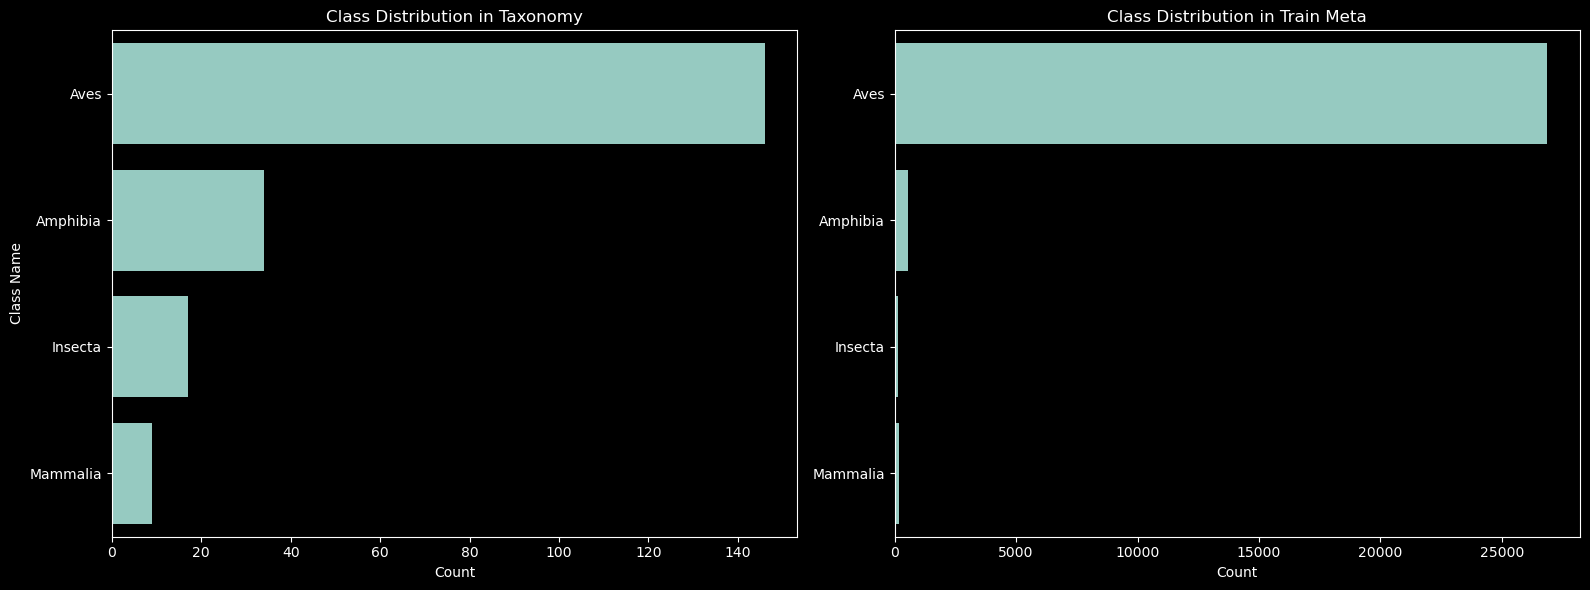

In [6]:
# Create side-by-side plots
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot for taxonomy
sns.countplot(
    data=taxonomy,
    y='class_name',
    order=taxonomy['class_name'].value_counts().index,
    ax=axs[0]
)
axs[0].set_title('Class Distribution in Taxonomy')
axs[0].set_xlabel('Count')
axs[0].set_ylabel('Class Name')

# Plot for train_meta
sns.countplot(
    data=train_meta,
    y='class_name',
    order=taxonomy['class_name'].value_counts().index,  # Same order for consistency
    ax=axs[1]
)
axs[1].set_title('Class Distribution in Train Meta')
axs[1].set_xlabel('Count')
axs[1].set_ylabel('')

plt.tight_layout()
plt.show()

We can see that there is a large class imbalance in the dataset. 

Unique primary labels in train_meta: 135


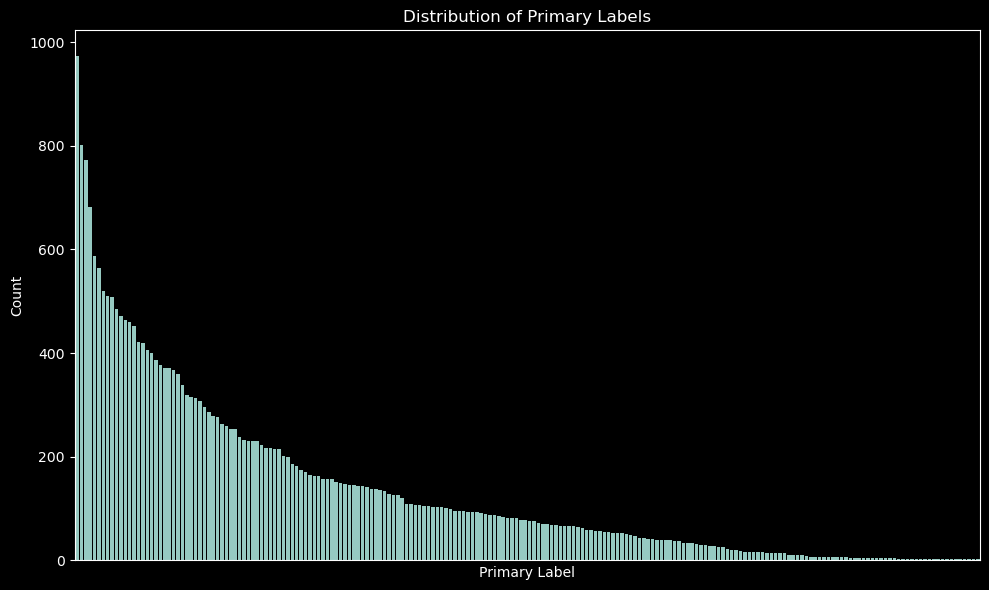

In [7]:
label_distribution = train_meta['primary_label'].value_counts()

print(f"Unique primary labels in train_meta: {label_distribution.nunique()}")

plt.figure(figsize=(10, 6))
sns.barplot(x=label_distribution.index, y=label_distribution.values)
plt.title('Distribution of Primary Labels')
plt.xlabel('Primary Label')
plt.ylabel('Count')
plt.xticks([])
plt.tight_layout()
plt.show()

As expected, the imbalance is also significant for primary labels. 

We filter out recordings with low quality based on their ratings. and those with to few classes

In [8]:
train_meta = train_meta[train_meta['rating'] >= 4]
label_counts = train_meta['primary_label'].value_counts()
valid_labels = label_counts[label_counts >= 30].index
train_meta = train_meta[train_meta['primary_label'].isin(valid_labels)]
print(train_meta.shape[0])

14283




Another problem is the large computational time for processing many audio files, so, we first decide to filter audio files based on their duration.

Measuring durations:   0%|          | 0/200 [00:00<?, ?it/s]

Measuring durations: 100%|██████████| 200/200 [00:00<00:00, 2159.95it/s]


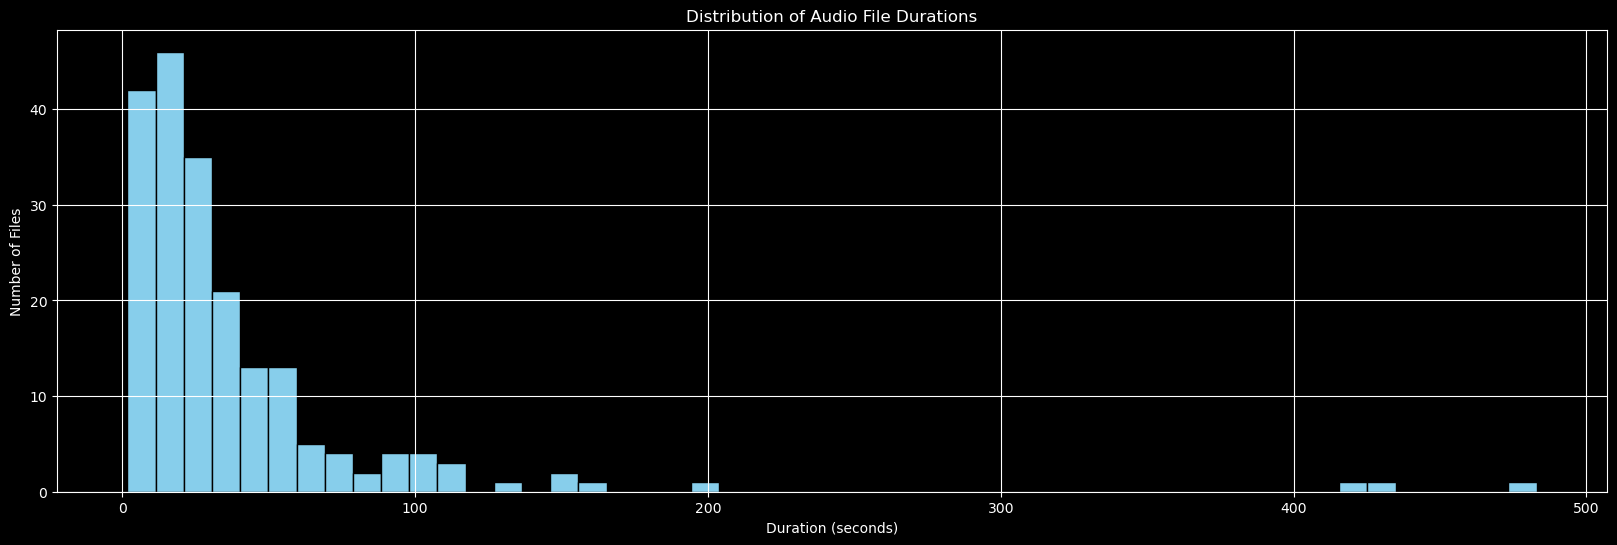

In [9]:
# sample
sampled_meta = train_meta.sample(n=200, random_state=42)
    
def get_duration(file_path):
    try:
        with sf.SoundFile(file_path) as f:
            duration = len(f) / f.samplerate
            return duration
    except Exception as e:
        print(f"Could not read {file_path}: {e}")
        return None

# Collect durations
durations = []
for path in tqdm(sampled_meta['file_path'], desc="Measuring durations"):
    durations.append(get_duration(path))

# Plot the distribution
plt.figure(figsize=(20, 6))
plt.hist(durations, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Audio File Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.grid(True)
plt.show()

We decide to keep files shorter than 20 seconds long.

Size before filtering: 14283


100%|██████████| 14283/14283 [00:11<00:00, 1209.08it/s]


Size after filtering: 5904



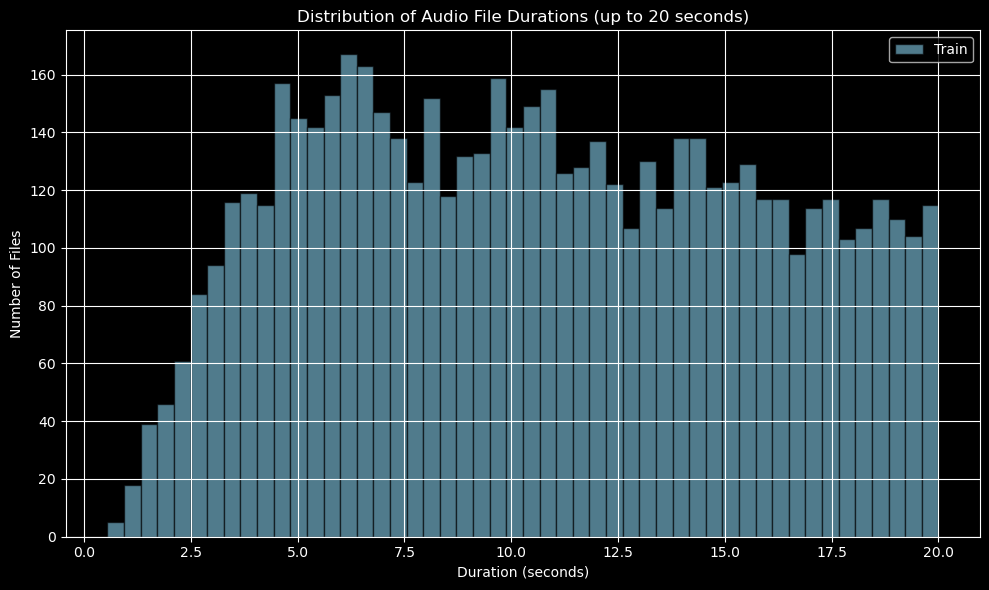

In [10]:
tqdm.pandas()

def filter_audio_duration(df, lower_bound, upper_bound):
    df['duration'] = df['file_path'].progress_apply(get_duration)
    df_filtered = df[
        (df['duration'] >= lower_bound) & (df['duration'] <= upper_bound)
    ].copy()
    return df_filtered

print(f"Size before filtering: {len(train_meta)}")

if not os.path.exists('filtered_duration.csv'):
    train_meta_filtered = filter_audio_duration(train_meta, 0, 20)
    train_meta_filtered.to_csv('filtered_duration.csv', index=False)
else:
    train_meta_filtered = pd.read_csv('filtered_duration.csv')
print(f"Size after filtering: {len(train_meta_filtered)}\n")


# Plot the filtered durations
plt.figure(figsize=(10, 6))
plt.hist(train_meta_filtered['duration'], bins=50, alpha=0.6, label='Train', color='skyblue', edgecolor='black')
plt.title("Distribution of Audio File Durations (up to 20 seconds)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Unique primary labels in train_meta_filtered: 
primary_label
grekis     183
greegr     182
yeofly1    150
trokin     148
soulap1    123
          ... 
rebbla1     12
cargra1     11
blcant4     11
rufmot1     10
yelori1     10
Name: count, Length: 117, dtype: int64

Unique primary labels in train_meta_filtered: 62


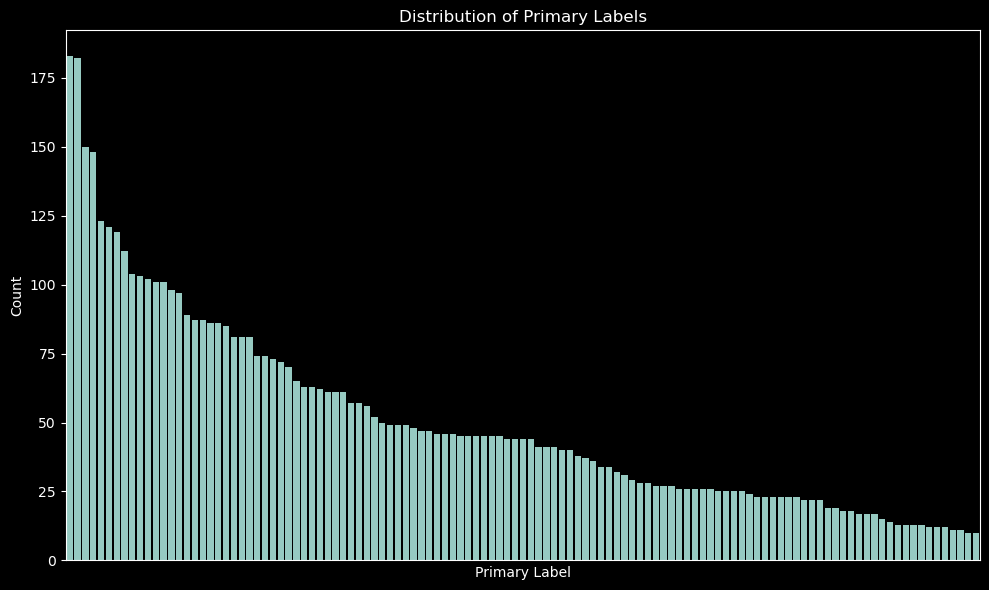

In [11]:
label_distribution = train_meta_filtered['primary_label'].value_counts()

print(f"Unique primary labels in train_meta_filtered: \n{label_distribution}\n")
print(f"Unique primary labels in train_meta_filtered: {label_distribution.nunique()}")

plt.figure(figsize=(10, 6))
sns.barplot(x=label_distribution.index, y=label_distribution.values)
plt.title('Distribution of Primary Labels')
plt.xlabel('Primary Label')
plt.ylabel('Count')
plt.xticks([])
plt.tight_layout()
plt.show()

We will also filter out species with 10 or less recordings, thus avoiding outliers and enabling stratifying.

Top 10 most populated labels:
primary_label
grekis     183
greegr     182
yeofly1    150
trokin     148
soulap1    123
sobtyr1    121
wbwwre1    119
bobfly1    112
banana     104
linwoo1    103
Name: count, dtype: int64
Unique primary labels in train_meta_filtered: 
primary_label
grekis     183
greegr     182
yeofly1    150
trokin     148
soulap1    123
sobtyr1    121
wbwwre1    119
bobfly1    112
banana     104
linwoo1    103
Name: count, dtype: int64

Unique primary labels in train_meta_filtered: 10


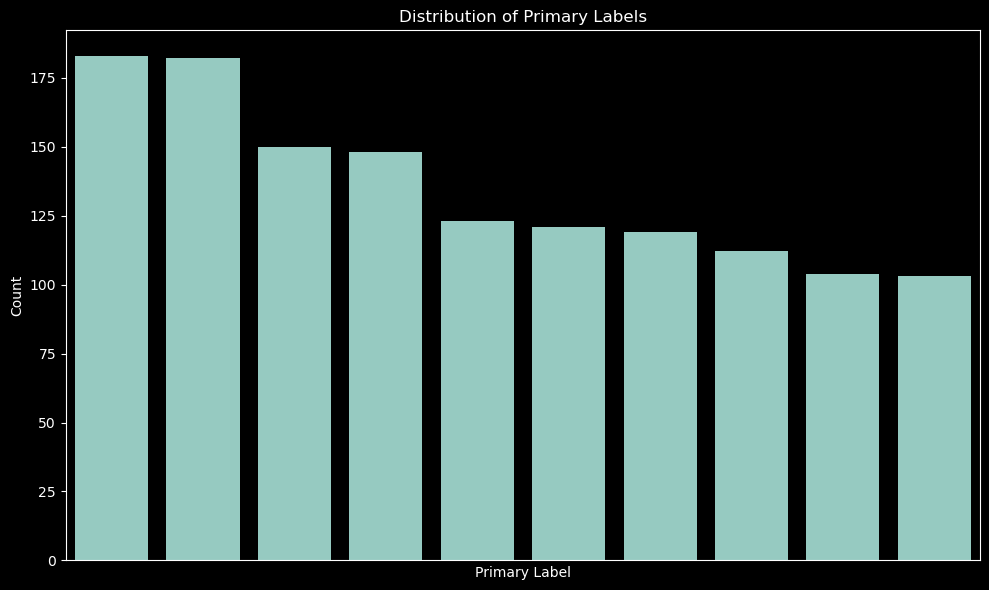

In [12]:
# label_counts = train_meta_filtered['primary_label'].value_counts()
# valid_labels = label_counts[label_counts >= 10].index
# train_meta_filtered = train_meta_filtered[train_meta_filtered['primary_label'].isin(valid_labels)].reset_index(drop=True).copy()

# label_distribution = train_meta_filtered['primary_label'].value_counts()
# print(f"Unique primary labels in train_meta_filtered: {label_distribution.nunique()}")
# print(f"Recordings: {train_meta_filtered.shape[0]}")

top_10_labels = label_distribution.head(10)
print("Top 10 most populated labels:")
print(top_10_labels)

train_meta_filtered = train_meta_filtered[train_meta_filtered['primary_label'].isin(top_10_labels.index)].reset_index(drop=True).copy()


label_distribution = train_meta_filtered['primary_label'].value_counts()

print(f"Unique primary labels in train_meta_filtered: \n{label_distribution}\n")
print(f"Unique primary labels in train_meta_filtered: {label_distribution.nunique()}")

plt.figure(figsize=(10, 6))
sns.barplot(x=label_distribution.index, y=label_distribution.values)
plt.title('Distribution of Primary Labels')
plt.xlabel('Primary Label')
plt.ylabel('Count')
plt.xticks([])
plt.tight_layout()
plt.show()


At this point we would like to split the data into a training set, test set and validation set, while stratifying, so that proportions are not lost for testing. However, since we've decided to use the sound files and locations for classifying, we need to aggregate the data first.

### Feature extraction

Based on the EDA and additional research, we decided to use Mel-Frequency Cepstral Coefficients (MFCCs) to train our model.

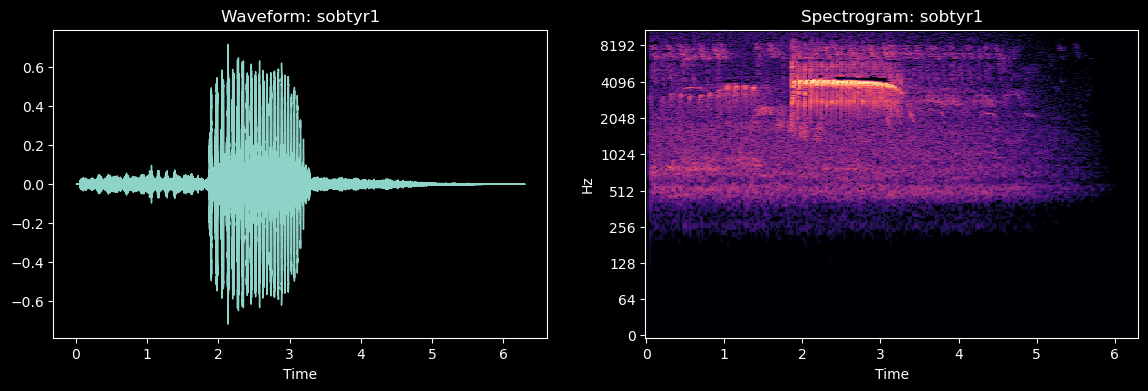

In [13]:
# lets explore an audio file
audio_examples = train_meta_filtered.sample(1)
file_path = audio_examples['file_path'].tolist()[0]
title = audio_examples['primary_label'].tolist()[0]


display(Audio(file_path))
y, sr = librosa.load(file_path)
# Plot waveform
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform: " + title )

# Plot spectrogram
plt.subplot(1, 2, 2)
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.title(f'Spectrogram: {title}')

plt.show()

In [14]:
# Feature Extraction (Simple MFCC)
def extract_mfcc(file_path, sr=22050, n_mfcc=20):
    """Extracts MFCC features from an audio file."""
    try:
        y, sr = librosa.load(file_path, sr=sr)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_processed = np.mean(mfccs.T, axis=0)  # Average across time
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None
    return mfccs_processed

# Example MFCC extraction
example_file = train_meta_filtered['file_path'].iloc[0]
mfccs = extract_mfcc(example_file)
print("\nMFCC Features Example:\n", mfccs)


MFCC Features Example:
 [-3.10778809e+02  4.46578484e+01  2.71186390e+01  1.04353428e+01
  5.49350083e-01  1.55537186e+01 -8.49652290e+00  1.27357235e+01
 -5.65302563e+00  9.63370228e+00 -2.75334865e-01  7.93281460e+00
 -1.75304532e+00  8.21178436e+00 -2.68474311e-01  5.21242809e+00
  9.41711962e-01  3.36466718e+00  6.95051432e-01  2.02012062e+00]


We extract the MFCC features, as well as the locations and aggregate them.

In [15]:
import os

if not os.path.exists('all_features.npy'):
    # Extract MFCC features
    features = []
    labels = []
    valid_indices = []

    for idx, row in tqdm(train_meta_filtered.iterrows(), total=len(train_meta_filtered), desc="Extracting train MFCCs"):
        mfccs = extract_mfcc(row['file_path'])
        if mfccs is not None:
            features.append(mfccs)
            labels.append(row['primary_label'])
            valid_indices.append(idx)

    mfccs = np.array(features)

    # Extract locations
    locations = train_meta_filtered.loc[valid_indices, ['longitude', 'latitude']].values
    # Concatenate audio and location features
    all_features = np.hstack([mfccs, locations])



    np.save('mfccs.npy', mfccs)
    np.save('locations.npy', np.array(locations))
    np.save('labels.npy', np.array(labels))
    np.save('all_features.npy', np.array(all_features))
else:
    print("all_features.npy already exists. Skipping feature extraction.")
    # Load features
    all_features = np.load('all_features.npy')
    mfccs = np.load('mfccs.npy')
    locations = np.load('locations.npy')
    labels = np.load('labels.npy')


Extracting train MFCCs: 100%|██████████| 1345/1345 [00:25<00:00, 52.21it/s]


In [16]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

np.save('labels_encoded.npy', np.array(labels_encoded))

In [17]:
# Feature Scaling
scaler = StandardScaler()
all_features_scaled = scaler.fit_transform(all_features)
mfccs_scaled = scaler.fit_transform(mfccs)

np.save('all_features_scaled.npy', all_features_scaled)
np.save('mfccs_scaled.npy', mfccs_scaled)

In [18]:
print(len(all_features_scaled))
print(len(mfccs_scaled))
print(len(labels_encoded))

1345
1345
1345


### Splitting and sampling functions

In [19]:
X = np.load('mfccs_scaled.npy')
X_all = np.load('all_features_scaled.npy')
y = np.load('labels_encoded.npy')

In [20]:
def split(X, y, test_size=0.2, validation=False, val_size=0.25):
    # train/test split
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # test/val split
    if validation:
        X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=val_size, random_state=42, stratify=y_train_full)
        return X_train, y_train, X_test, y_test, X_val, y_val
    else:
        return X_train_full, y_train_full, X_test, y_test, None, None


In [21]:
def remove_classes_under(X, y, min_instances=20):
    class_counts = Counter(y)
    
    # Get valid classes
    valid_classes = {cls for cls, count in class_counts.items() if count >= min_instances}
    
    # Create mask for valid samples
    mask = np.array([label in valid_classes for label in y])
    
    # Filter X and y
    X_filtered = X[mask]
    y_filtered = y[mask]

    return X_filtered, y_filtered

In [22]:
def sample(X, y, sample_fraction=0.5, random_state=42):
    X, _, y, _ = train_test_split(
        X, y,
        train_size=sample_fraction,
        stratify=y,
        random_state=random_state
    )
    return X, y 

## Training Models
- Random Forest
- KNN
- Naive Bayes
- SVM
- Perceptron

In [23]:
def evaluate_model(model, X_test, y_test, model_name="Model", class_labels=None):
    """
    Evaluates a classifier with metrics and plots.

    This function handles both models that can and cannot produce probability scores.

    Parameters:
    - model: The trained classifier object.
    - X_test (array-like): The test feature data.
    - y_test (array-like): The true test labels.
    - base_model_name (str): The name of the model for titles and printouts.
    - class_labels (list of str, optional): The original string names of the classes
      for more readable plot labels. If None, integer labels are used.
    """
    print(f"\n{'='*20} Evaluating {model_name} {'='*20}")

    # --- 1. Basic Metrics from Predictions ---
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted Precision: {prec:.4f}")
    print(f"Weighted Recall: {rec:.4f}")
    print(f"Weighted F-score: {f1:.4f}\n")

    # --- 2. Prepare figure with 3 horizontal subplots ---
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_labels if class_labels is not None else np.unique(y_test),
                yticklabels=class_labels if class_labels is not None else np.unique(y_test))
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    # --- 3. Probability-based Curves (ROC and Precision-Recall) ---
    # Check if the model has the 'predict_proba' method
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
        classes = np.unique(y_test)
        y_test_bin = label_binarize(y_test, classes=classes)

        # ROC
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color='deeppink', linestyle=':', linewidth=2,
                     label=f'Micro-average ROC (AUC = {roc_auc:.2f})')
        axes[1].plot([0, 1], [0, 1], 'k--')
        axes[1].set_title("ROC Curve")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].legend(loc='lower right')
        axes[1].grid(True)

        # Precision-Recall
        precision, recall, _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
        axes[2].plot(recall, precision, color='navy', linestyle=':', linewidth=2)
        axes[2].set_title("Precision-Recall Curve")
        axes[2].set_xlabel("Recall")
        axes[2].set_ylabel("Precision")
        axes[2].grid(True)

    else:
        axes[1].text(0.5, 0.5, 'No probability output\nROC skipped',
                     ha='center', va='center', fontsize=12)
        axes[2].text(0.5, 0.5, 'No probability output\nPR skipped',
                     ha='center', va='center', fontsize=12)
        axes[1].axis('off')
        axes[2].axis('off')

    fig.suptitle(f"{model_name} Evaluation", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### Random Forest

--- Training XGBoost Model ---
Using a sample of 1345 instances with 10 classes.
Training data shape: (1076, 22)
Applying SMOTE to the training data...
Training data shape after SMOTE: (1470, 22)
Number of classes: 10

Training the model...


Fitting 3 folds for each of 405 candidates, totalling 1215 fits
Best parameters: {'colsample_bytree': 0.8, 'gamma': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'subsample': 0.8}
Test accuracy: 0.5204460966542751

==================== Evaluating Best XGBoost Classifier ====================
Accuracy: 0.5204
Weighted Precision: 0.5706
Weighted Recall: 0.5204
Weighted F-score: 0.5292



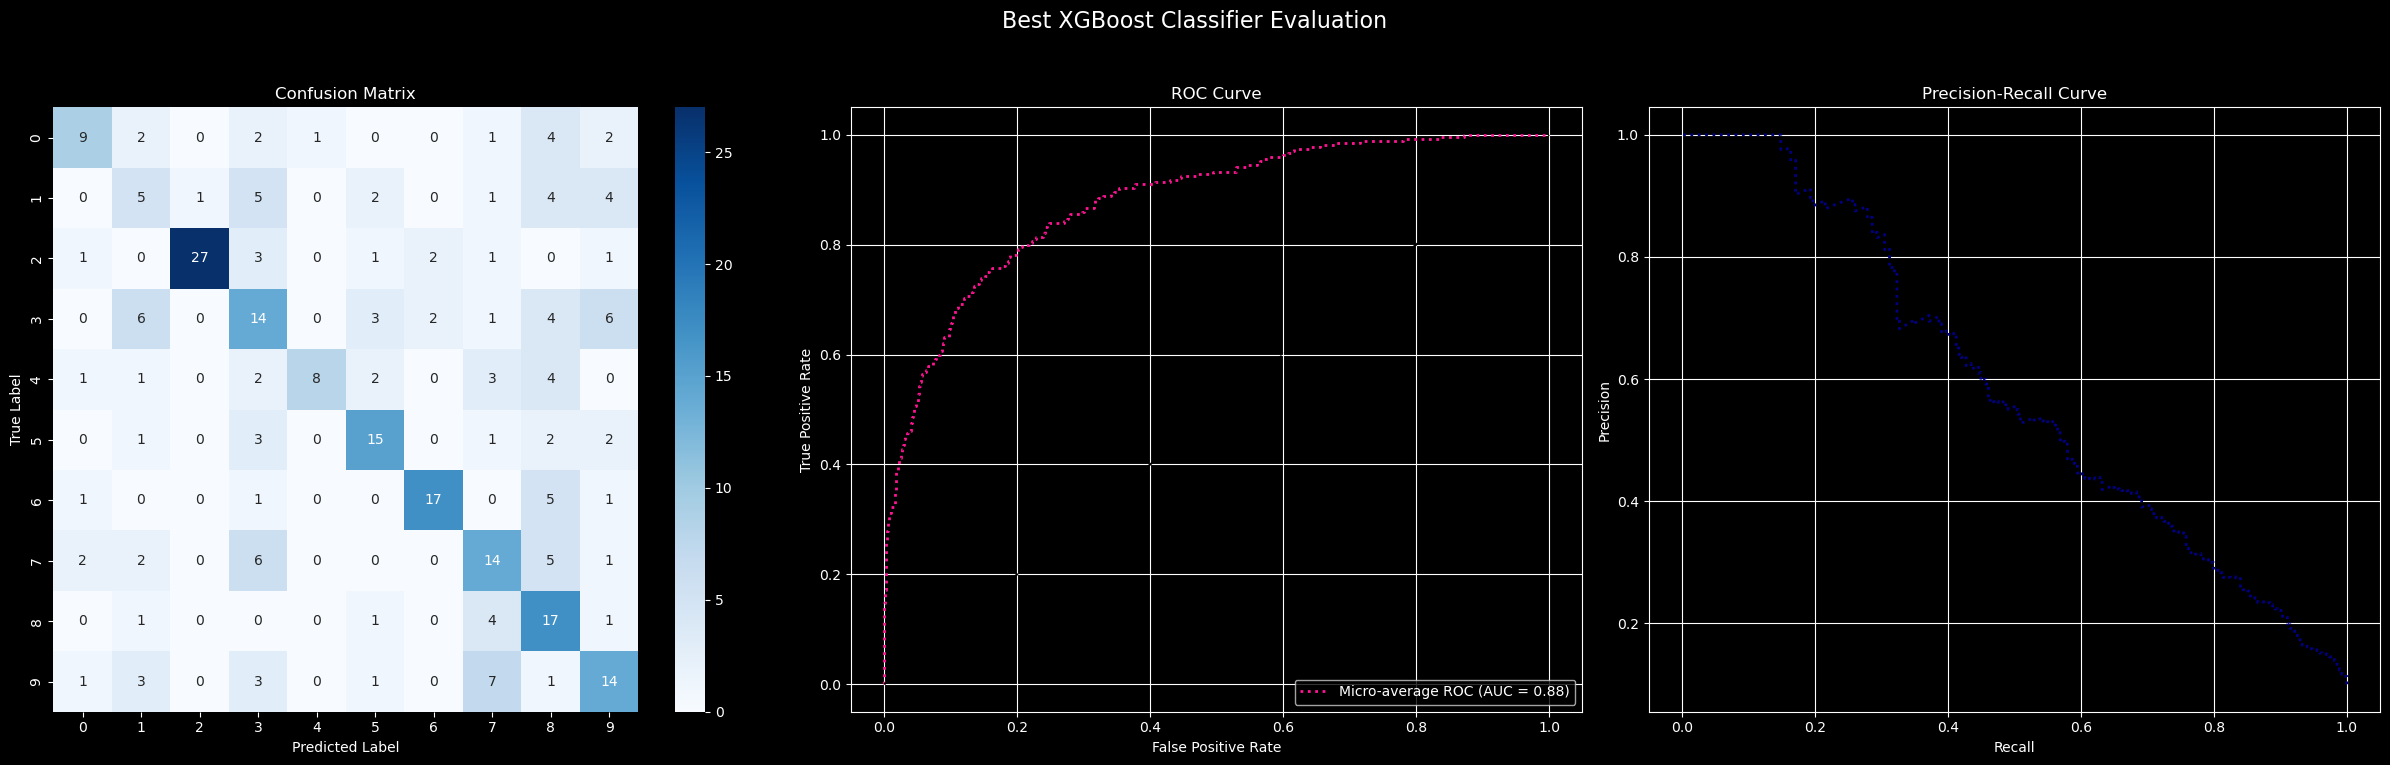

In [24]:
def train_XGB_model(X, y):
    """
    Trains, evaluates, and visualizes a simple XGBoost model,
    """
    print("--- Training XGBoost Model ---")

    #  Sample and clean the data

    print(f"Using a sample of {X.shape[0]} instances with {len(np.unique(y))} classes.")



    local_le = LabelEncoder()
    y_relabled = local_le.fit_transform(y)
    
    
    #  Split data into training and testing sets
    X_train, y_train, X_test, y_test, _, _ = split(X, y_relabled)

    print(f"Training data shape: {X_train.shape}")

    # Handle class imbalance
    print("Applying SMOTE to the training data...")
    min_class_count = np.min(np.unique(y_train, return_counts=True)[1])
    k_neighbors = min(2, min_class_count - 1) if min_class_count > 1 else 1
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    n_classes = len(np.unique(y_train))
    print(f"Training data shape after SMOTE: {X_train.shape}")
    print(f"Number of classes: {n_classes}")

    # Define and train the XGBoost model
    base_model = xgb.XGBClassifier(
        objective="multi:softprob",
        random_state=42,
    )

    print("\nTraining the model...")
    base_model.fit(X_train, y_train)

    params = {
            'min_child_weight': [1, 3, 5],
            'gamma': [0.1, 0.5, 1, 2, 5],
            'subsample': [0.4, 0.6, 0.8],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'max_depth': [3, 5, 7]
    }

    # Perform hyperparameter tuning using GridSearchCV
    grid_search = GridSearchCV(
        base_model,
        param_grid=params,
        scoring='accuracy',
        cv=3,
        verbose=1,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    # Best model
    best_model = grid_search.best_estimator_


    print("Best parameters:", grid_search.best_params_)

    # Evaluate on test set
    y_pred = best_model.predict(X_test)
    print("Test accuracy:", accuracy_score(y_test, y_pred))

    evaluate_model(best_model, X_test, y_test, model_name="Best XGBoost Classifier")

    return best_model

# Run the updated function
best_model = train_XGB_model(X_all, y)




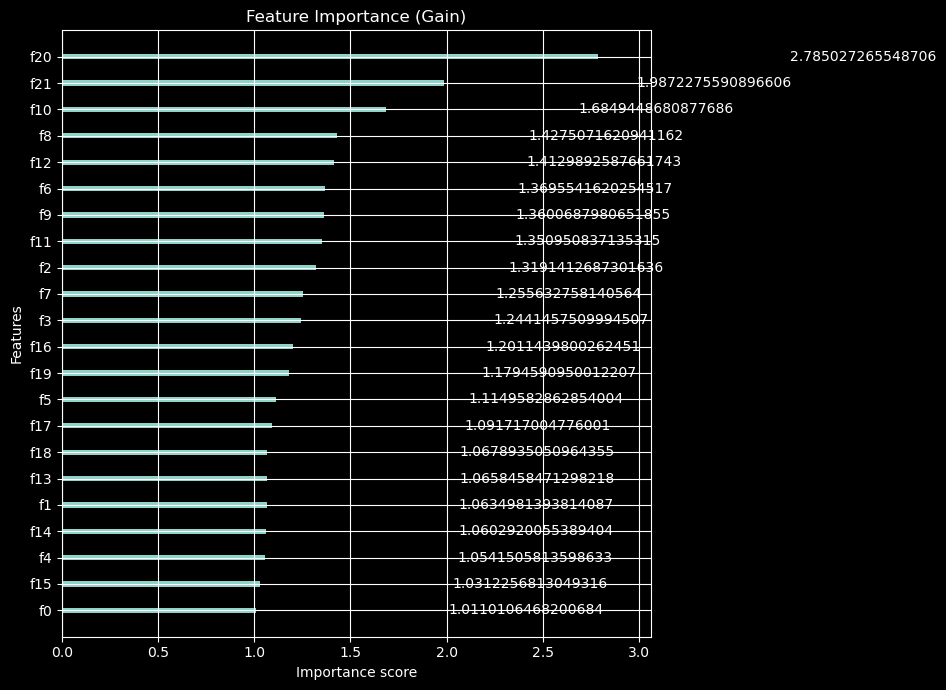

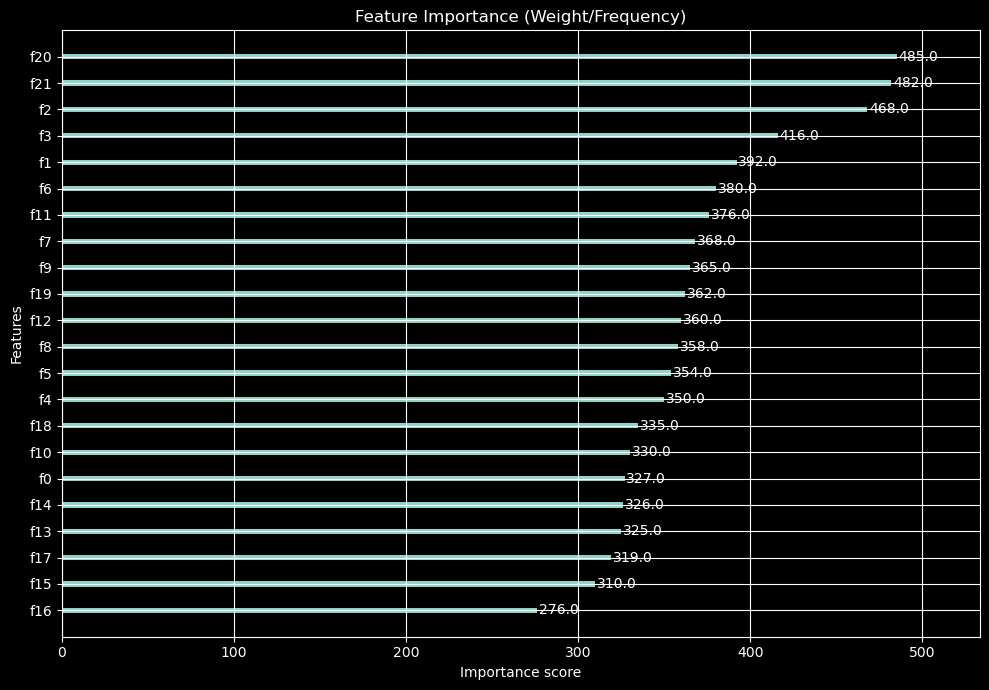

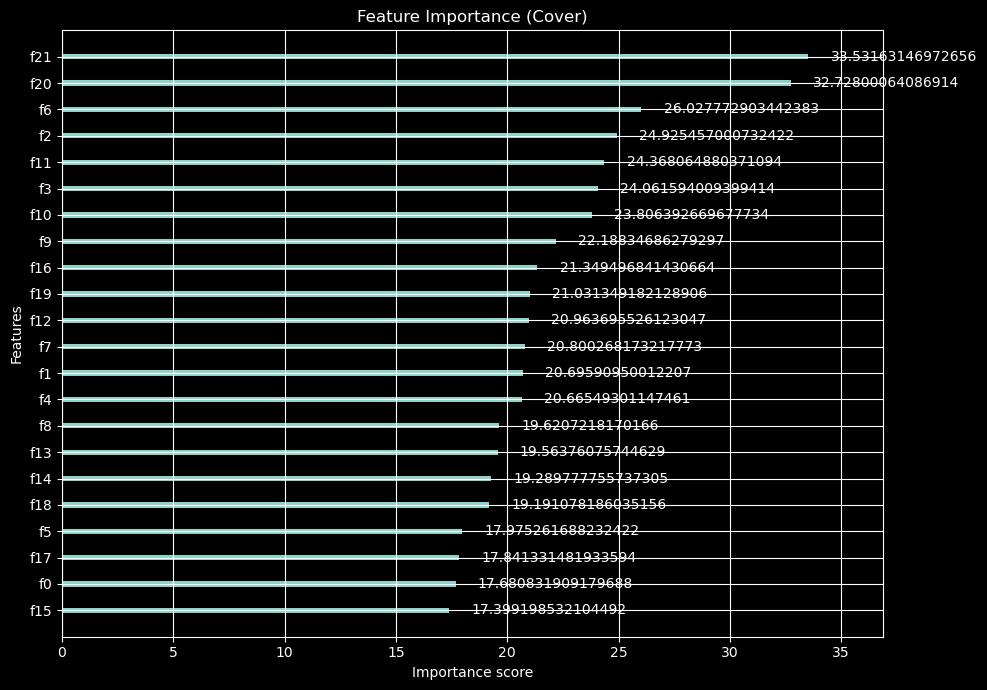

--- Training XGBoost Model ---
Using a sample of 1345 instances with 10 classes.
Training data shape: (1076, 19)
Applying SMOTE to the training data...
Training data shape after SMOTE: (1470, 19)
Number of classes: 10

Training the model...
Fitting 3 folds for each of 405 candidates, totalling 1215 fits
Best parameters: {'colsample_bytree': 0.8, 'gamma': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'subsample': 0.8}
Test accuracy: 0.5278810408921933

==================== Evaluating Best XGBoost Classifier ====================
Accuracy: 0.5279
Weighted Precision: 0.5453
Weighted Recall: 0.5279
Weighted F-score: 0.5306



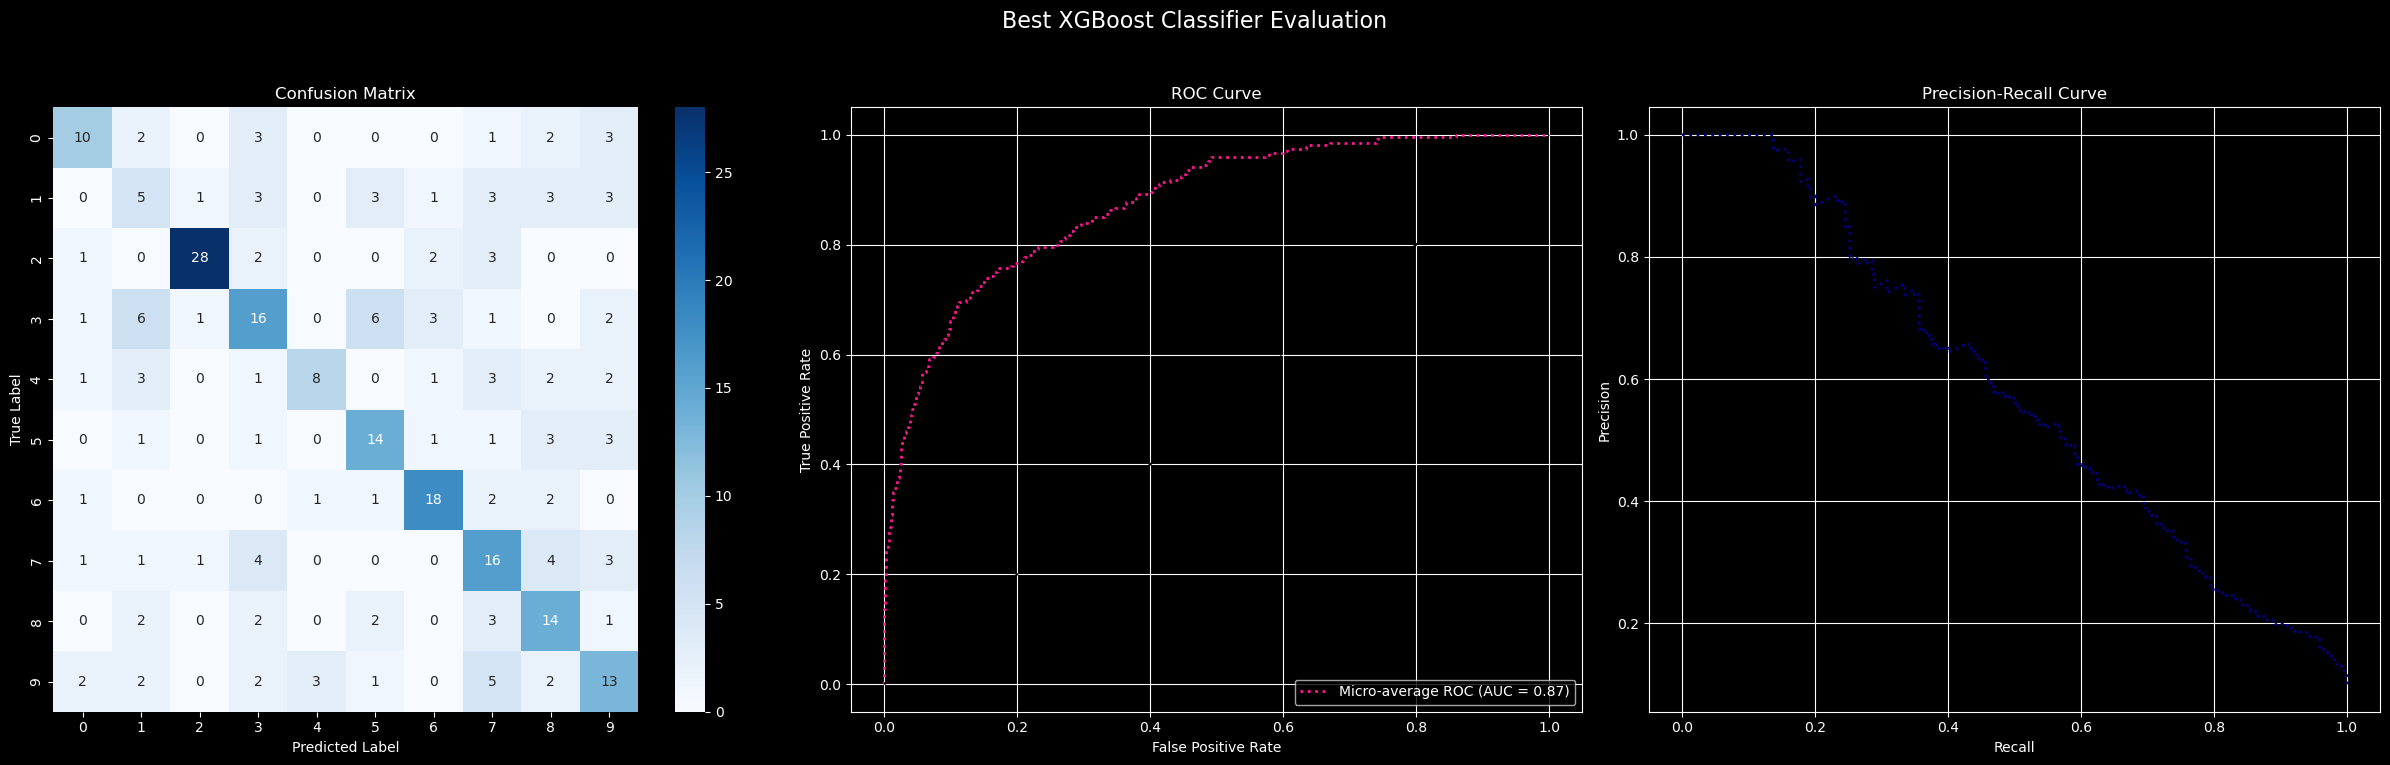

In [25]:
# chekc if we have two many features
plt.figure(figsize=(10, 7))
xgb.plot_importance(best_model, importance_type='gain', ax=plt.gca(), title='Feature Importance (Gain)')
plt.tight_layout()
plt.show()

# Get feature importances by gain
importances_gain = best_model.feature_importances_

# Get indices of the 3 lowest features by gain
lowest_indices = importances_gain.argsort()[:3]

plt.figure(figsize=(10, 7))
xgb.plot_importance(best_model, importance_type='weight', ax=plt.gca(), title='Feature Importance (Weight/Frequency)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
xgb.plot_importance(best_model, importance_type='cover', ax=plt.gca(), title='Feature Importance (Cover)')
plt.tight_layout()
plt.show()


# If you have already scaled features, drop from those as well
all_features_scaled = np.delete(all_features_scaled, lowest_indices, axis=1)


X_all = all_features_scaled

# Re-train the model with the updated features
best_model = train_XGB_model(X_all, y)


it very slightly improved, so we will keep it

/nix/store/ws5v6mj2g1kgqgxz7fssi2hnvplvd4zj-python3-3.13.4-env/lib/python3.13/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


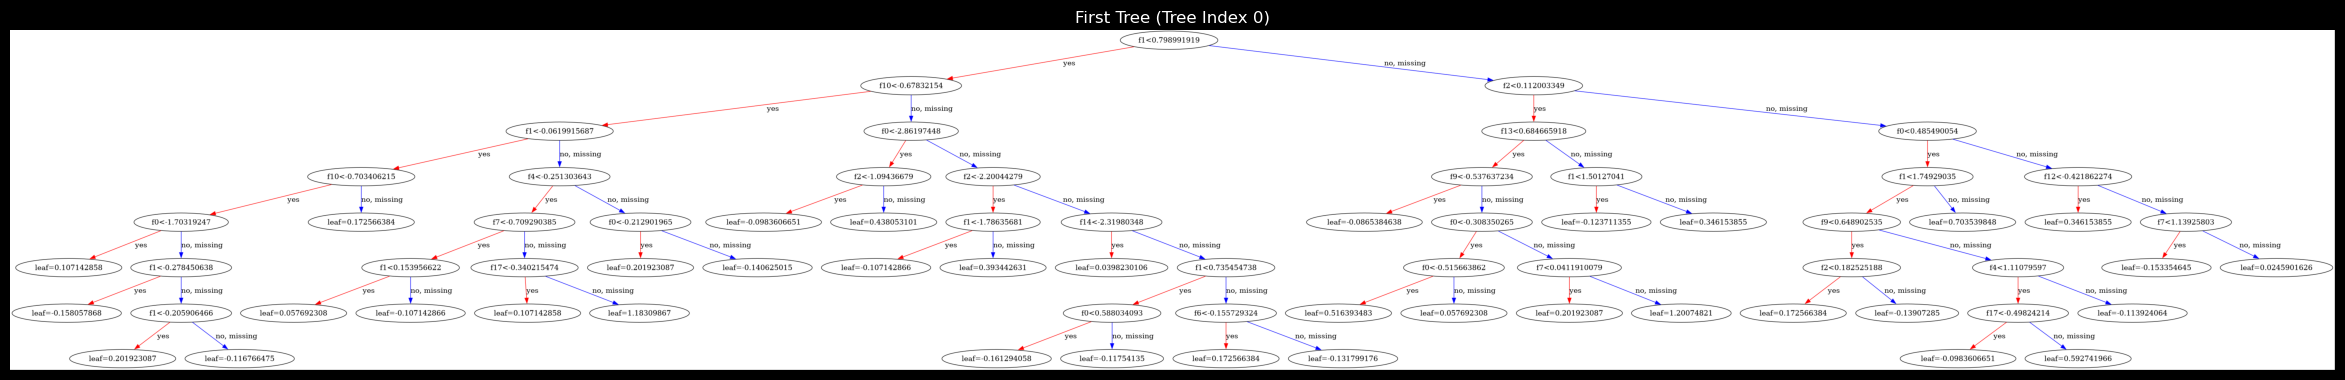

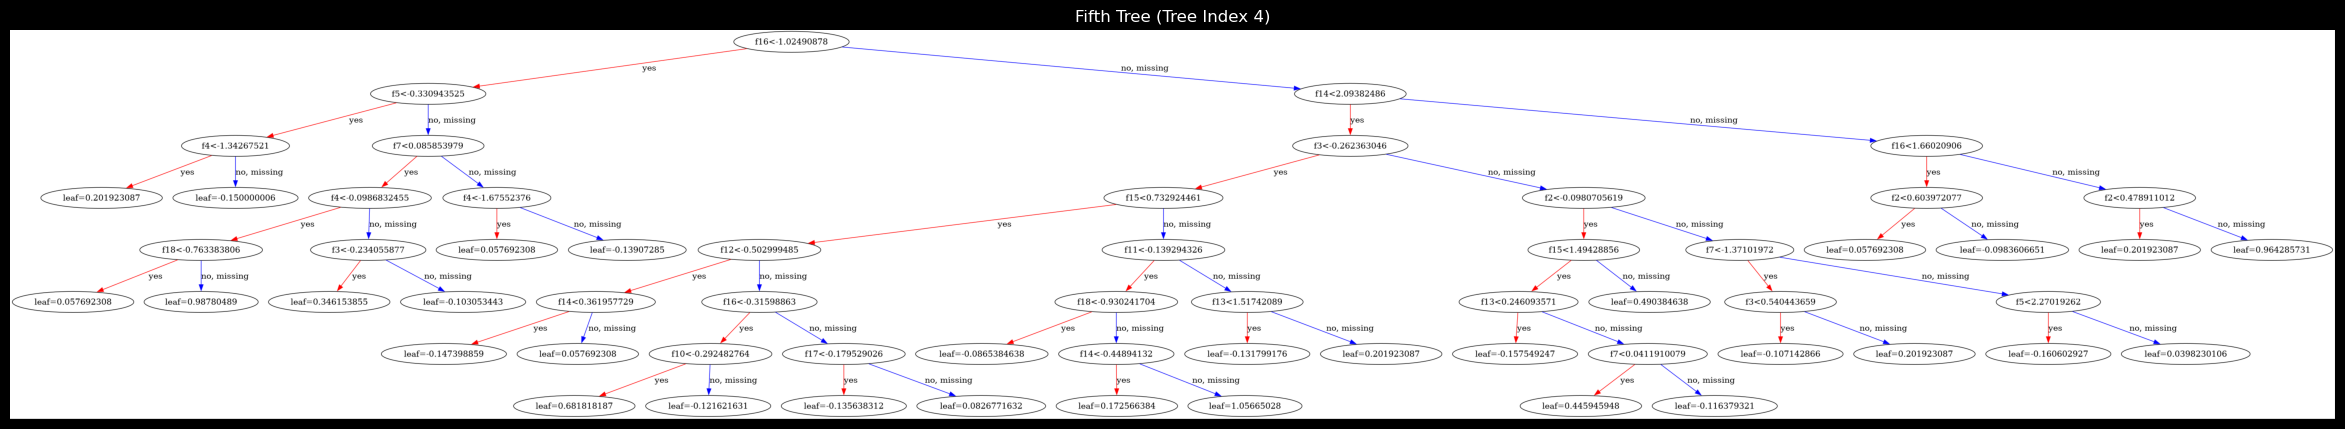

In [26]:
plt.rcParams['figure.figsize'] = [30, 20] 

plot_tree(best_model, num_trees=0)
plt.title("First Tree (Tree Index 0)")
plt.show()

plot_tree(best_model, num_trees=4) 
plt.title("Fifth Tree (Tree Index 4)")
plt.show()

### KNN

--- Training KNN Model ---
Using a sample of 1345 instances with 10 classes.
Applying SMOTE to the training data...
Training data shape after SMOTE: (1470, 19)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
KNN grid search train time: 0.38s
Best parameters found: {'n_neighbors': 3, 'p': 2}

==================== Evaluating K Nearest Neighbours ====================
Accuracy: 0.4238
Weighted Precision: 0.5256
Weighted Recall: 0.4238
Weighted F-score: 0.4441



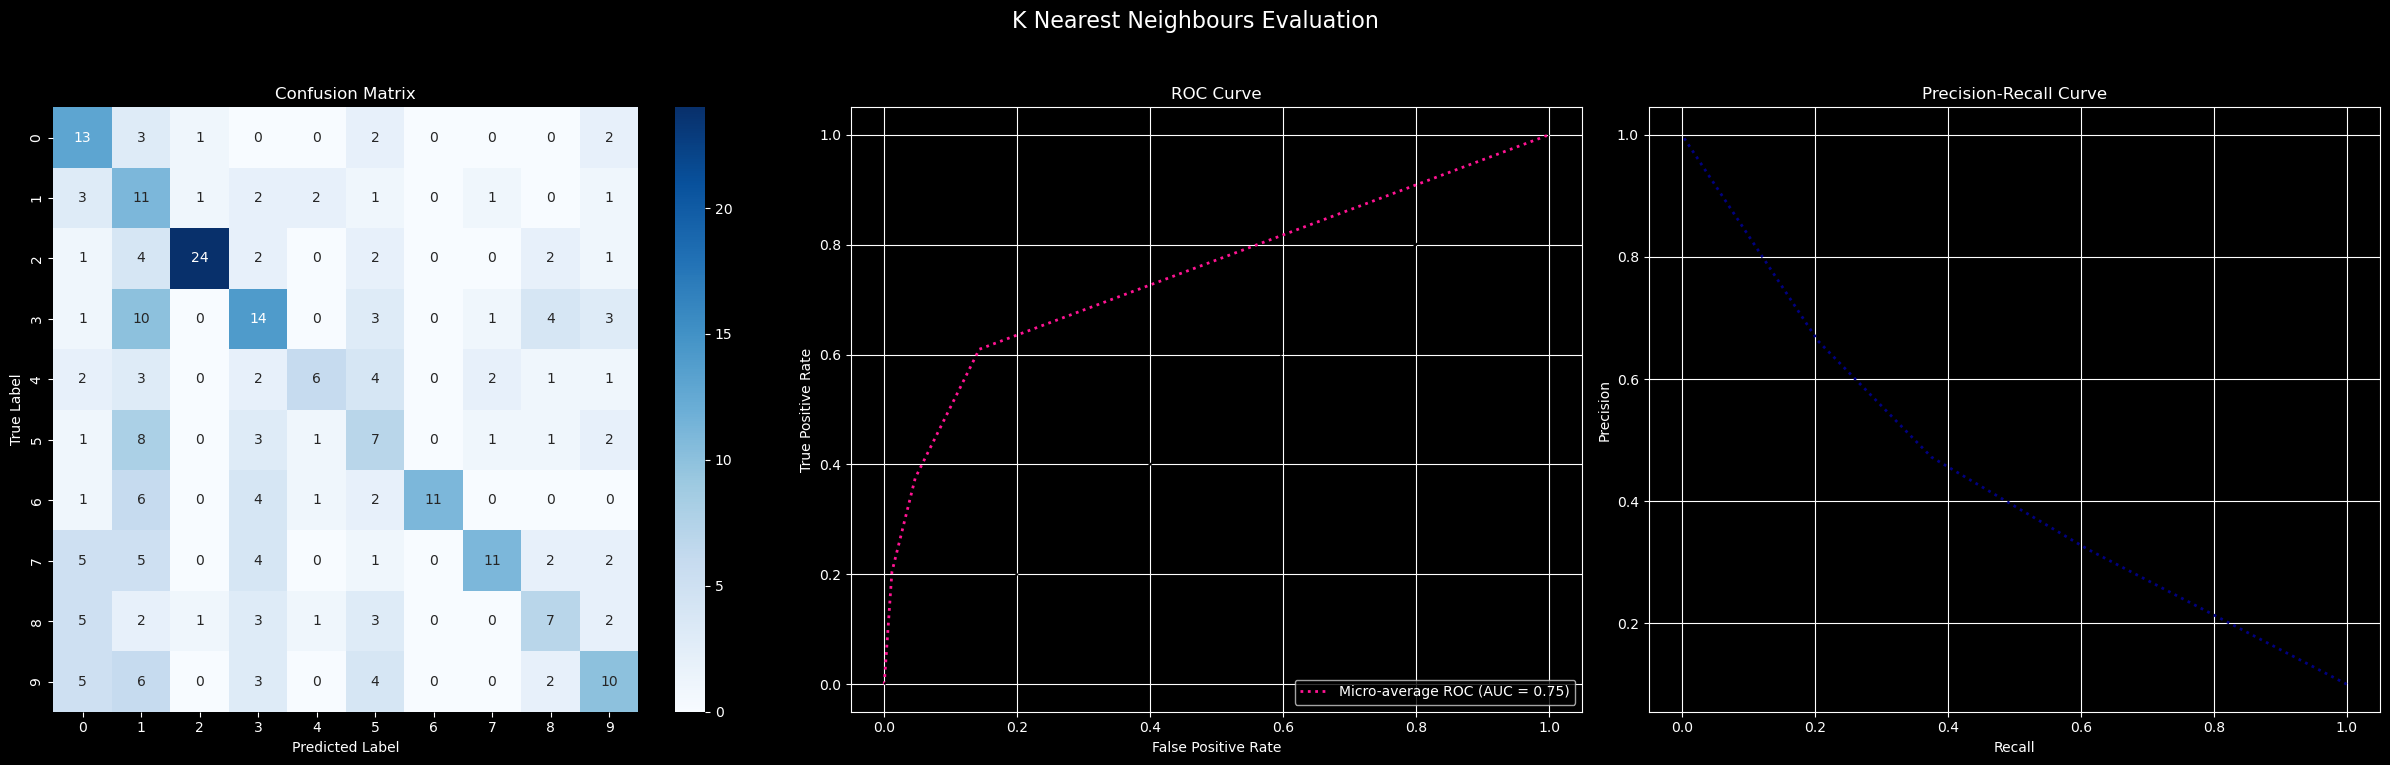

In [27]:
def train_KNN_model(X, y):
    print("--- Training KNN Model ---")

    # Sample and clean
    X_sampled, y_sampled = X, y
    print(f"Using a sample of {X_sampled.shape[0]} instances with {len(np.unique(y_sampled))} classes.")

    # Split
    X_train, y_train, X_test, y_test, _, _ = split(X_sampled, y_sampled)

    # Resample
    print("Applying SMOTE to the training data...")
    smote = SMOTE(random_state=42, k_neighbors=2)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print(f"Training data shape after SMOTE: {X_train.shape}")

    # Train model
    base_model = KNeighborsClassifier(n_neighbors=3, p=1)

    # Grid search parameters
    param_grid = {
        'n_neighbors': [3, 5, 7, 9],
        'p': [1, 2]  # Manhattan (p=1) and Euclidean (p=2) distances
    }

    # Run grid search
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring='accuracy',
        cv=3,
        verbose=1,
        n_jobs=-1
    )

    start_train = time.time()
    grid_search.fit(X_train, y_train)
    print(f"KNN grid search train time: {time.time() - start_train:.2f}s")
    print("Best parameters found:", grid_search.best_params_)

    best_model = grid_search.best_estimator_

    # 6. Evaluate the model using our universal function
    evaluate_model(best_model, X_test, y_test, model_name="K Nearest Neighbours")

train_KNN_model(X_all, y)

### Naive Bayes

--- Training NB Model ---
Using a sample of 1345 instances with 10 classes.
Applying SMOTE to the training data...
Training data shape after SMOTE: (1470, 19)
Fitting 3 folds for each of 4 candidates, totalling 12 fits
GNB grid search train time: 0.03s
Best parameters found: {'var_smoothing': 1e-09}

==================== Evaluating Naive Bayes ====================
Accuracy: 0.3717
Weighted Precision: 0.4217
Weighted Recall: 0.3717
Weighted F-score: 0.3778



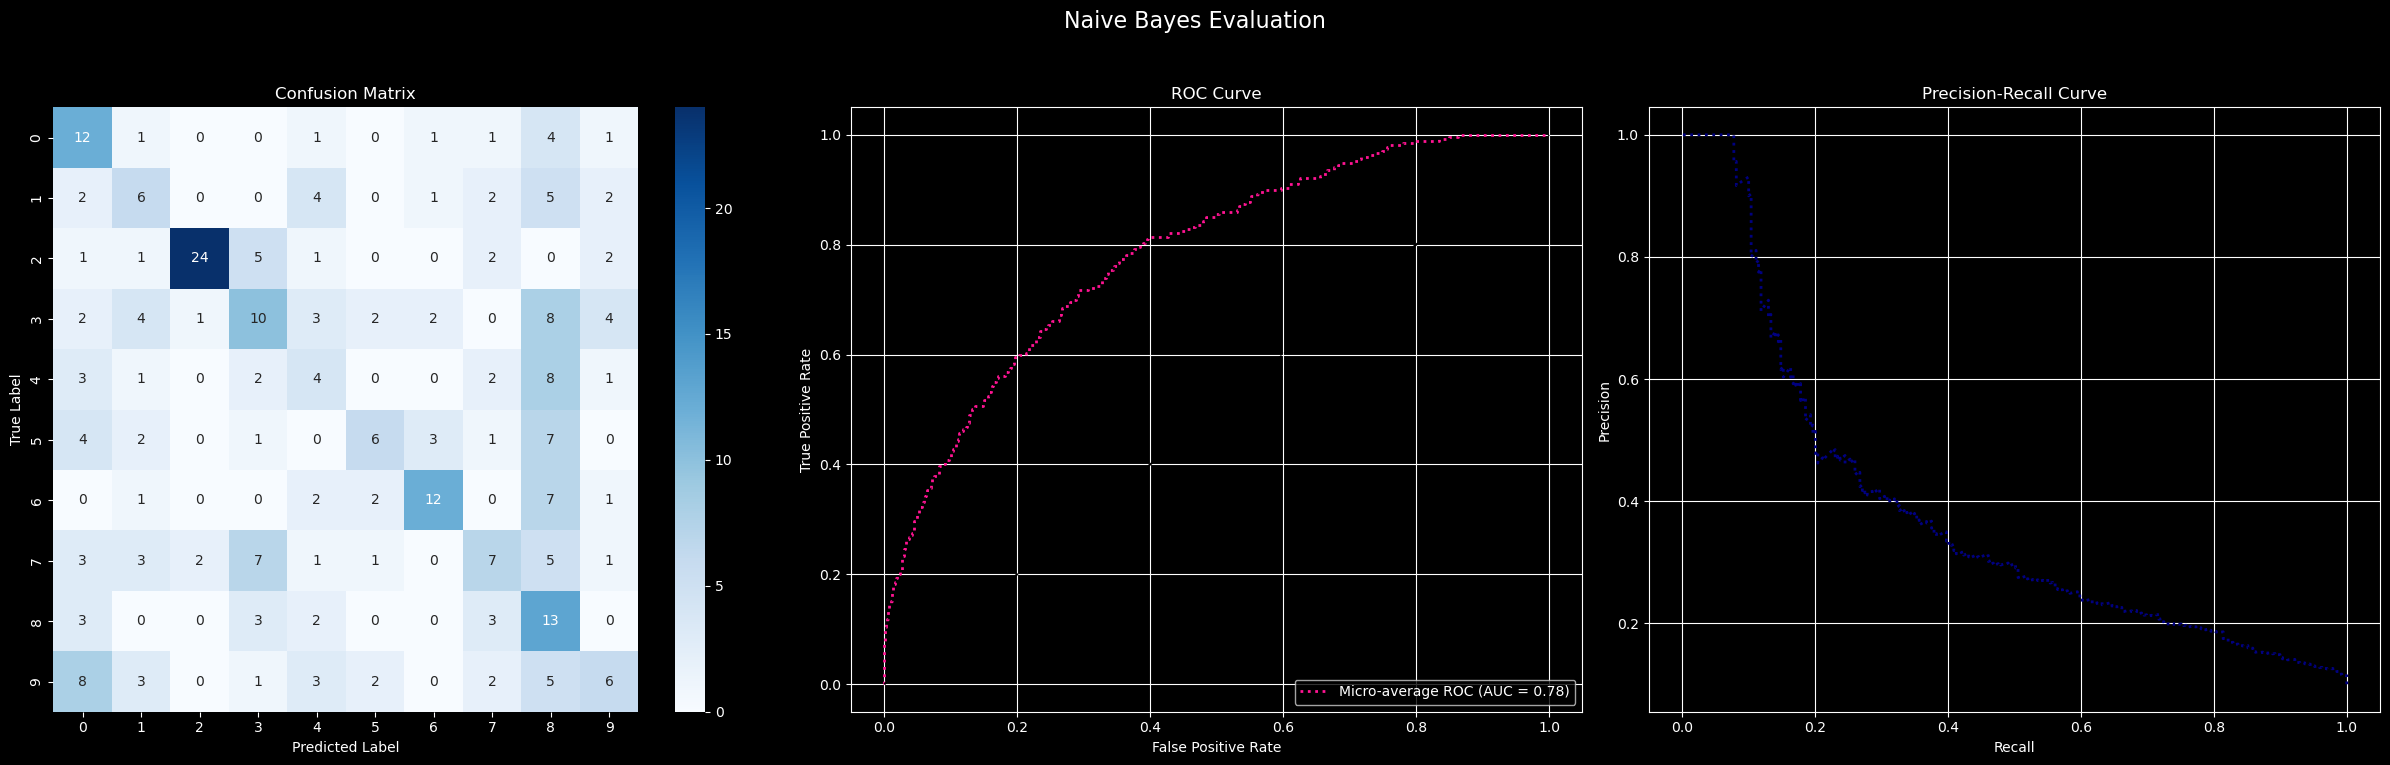

In [28]:
def train_GNB_model(X, y):

    print("--- Training NB Model ---")

    # Sample and clean
    X_sampled, y_sampled = X, y
    print(f"Using a sample of {X_sampled.shape[0]} instances with {len(np.unique(y_sampled))} classes.")

    # Split
    X_train, y_train, X_test, y_test, _, _ = split(X_sampled, y_sampled)

    # Resample
    print("Applying SMOTE to the training data...")
    smote = SMOTE(random_state=42, k_neighbors=2)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print(f"Training data shape after SMOTE: {X_train.shape}")

    base_model = GaussianNB()

    # Grid search parameters
    param_grid = {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    }

    # Run grid search
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring='accuracy',
        cv=3,
        verbose=1,
        n_jobs=-1
    )

    start_train = time.time()
    grid_search.fit(X_train, y_train)
    print(f"GNB grid search train time: {time.time() - start_train:.2f}s")
    print("Best parameters found:", grid_search.best_params_)

    best_model = grid_search.best_estimator_

    # 6. Make predictions and evaluate performance
    evaluate_model(best_model, X_test, y_test, model_name="Naive Bayes")

train_GNB_model(X_all, y)


### SVM

--- Training SVC Model ---
Using a sample of 1345 instances with 10 classes.
Applying SMOTE to the training data...
Training data shape after SMOTE: (1470, 19)

--- Kernel: linear ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Train time: 5.19s
Best params for linear kernel: {'C': 10}

==================== Evaluating Support Vector Machine (linear) ====================
Accuracy: 0.4015
Weighted Precision: 0.4147
Weighted Recall: 0.4015
Weighted F-score: 0.3997



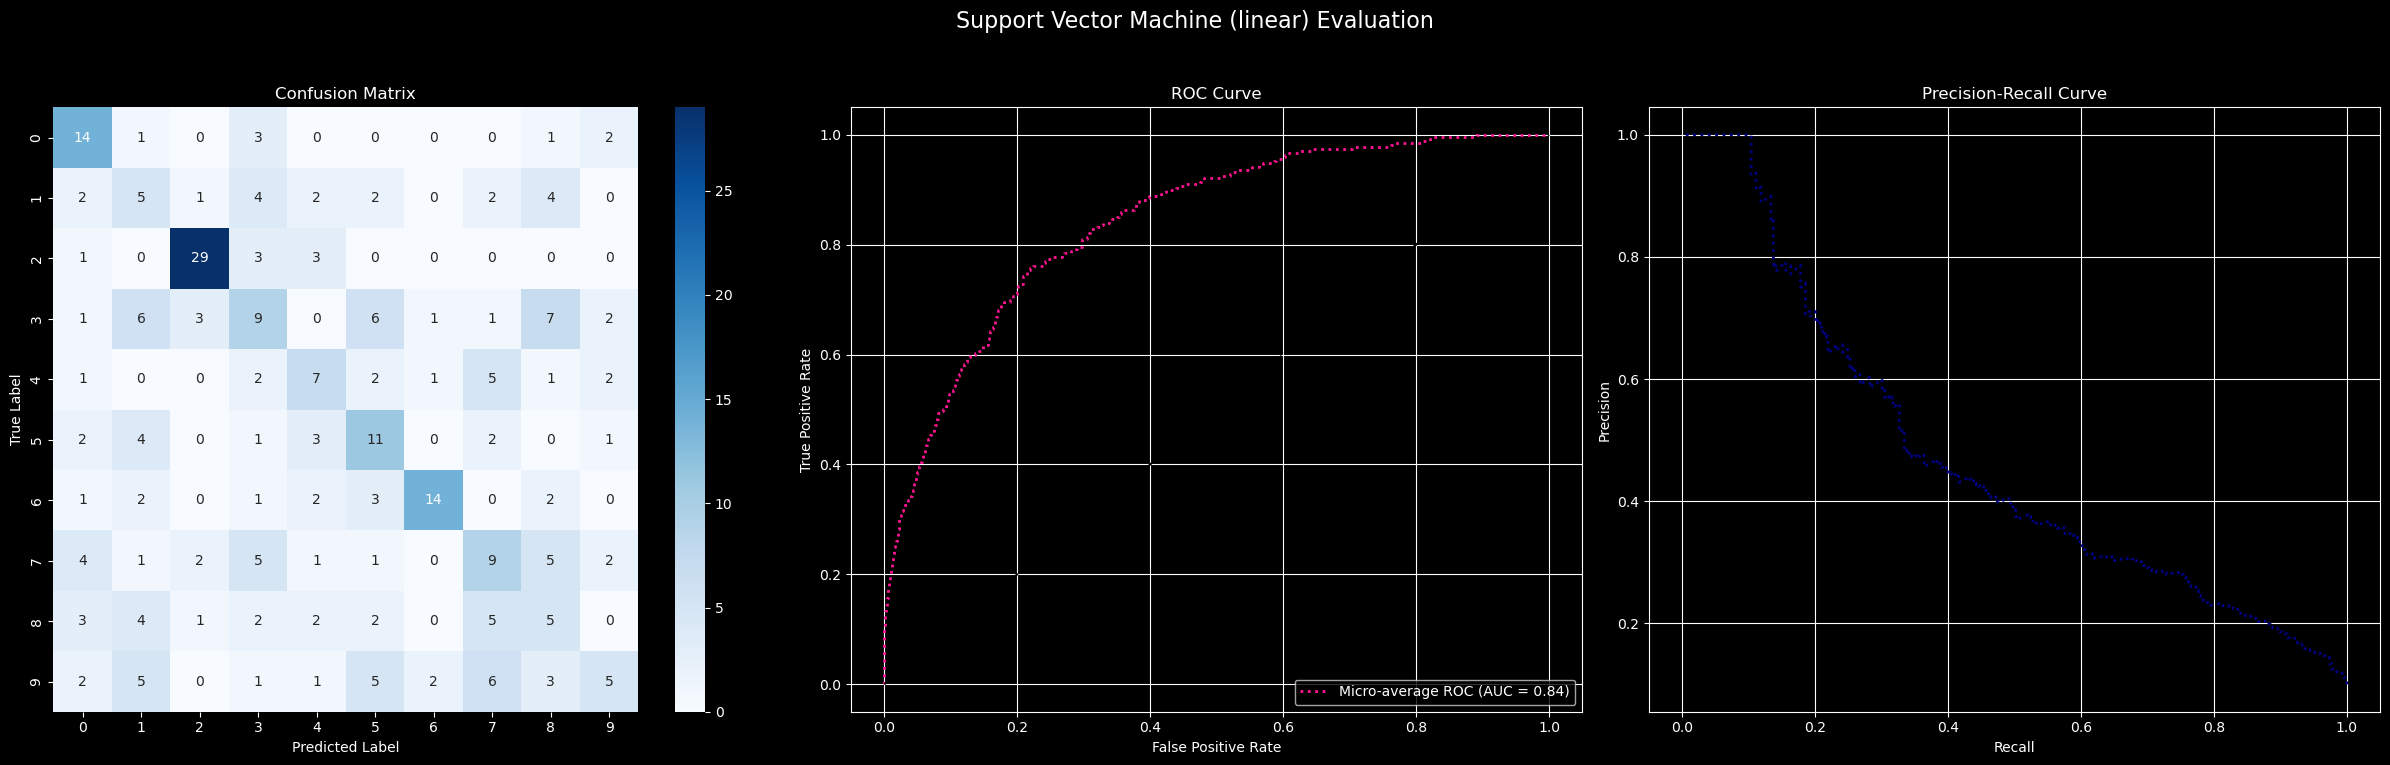


--- Kernel: poly ---
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Train time: 1.51s
Best params for poly kernel: {'C': 10, 'degree': 3, 'gamma': 'scale'}

==================== Evaluating Support Vector Machine (poly) ====================
Accuracy: 0.4349
Weighted Precision: 0.4707
Weighted Recall: 0.4349
Weighted F-score: 0.4391



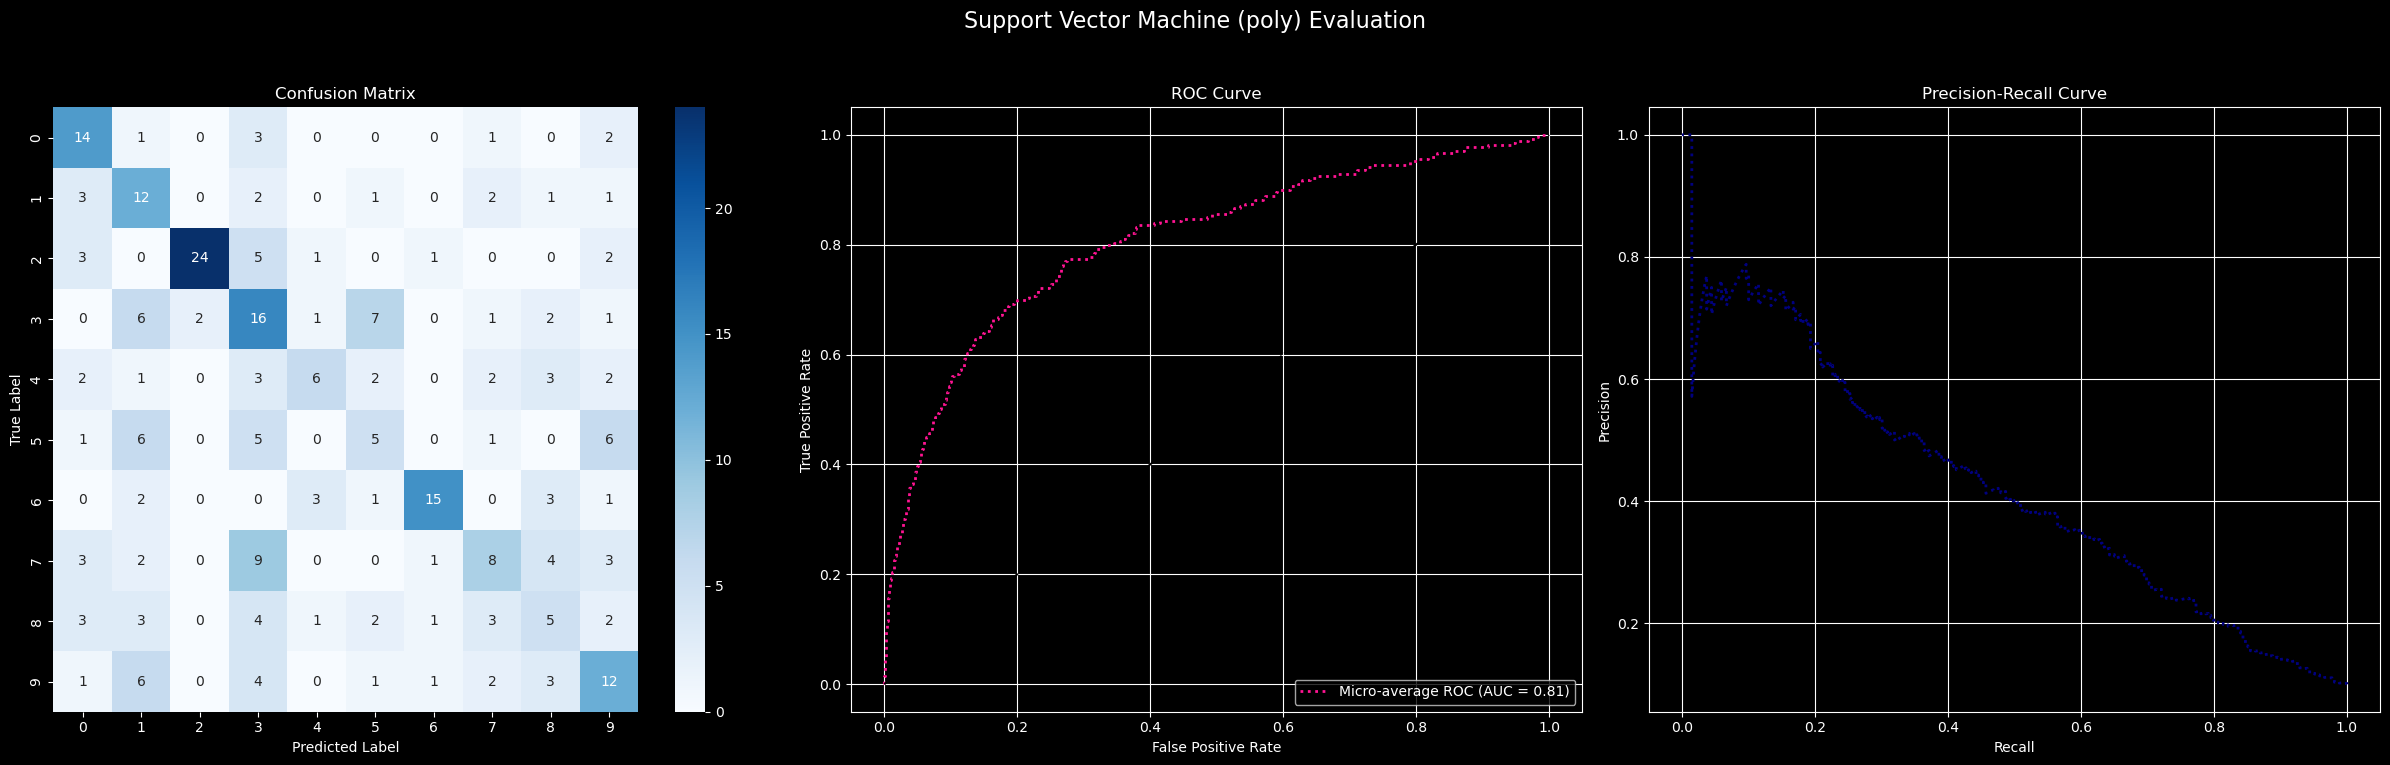


--- Kernel: rbf ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Train time: 1.79s
Best params for rbf kernel: {'C': 10, 'gamma': 0.1}

==================== Evaluating Support Vector Machine (rbf) ====================
Accuracy: 0.5204
Weighted Precision: 0.5459
Weighted Recall: 0.5204
Weighted F-score: 0.5233



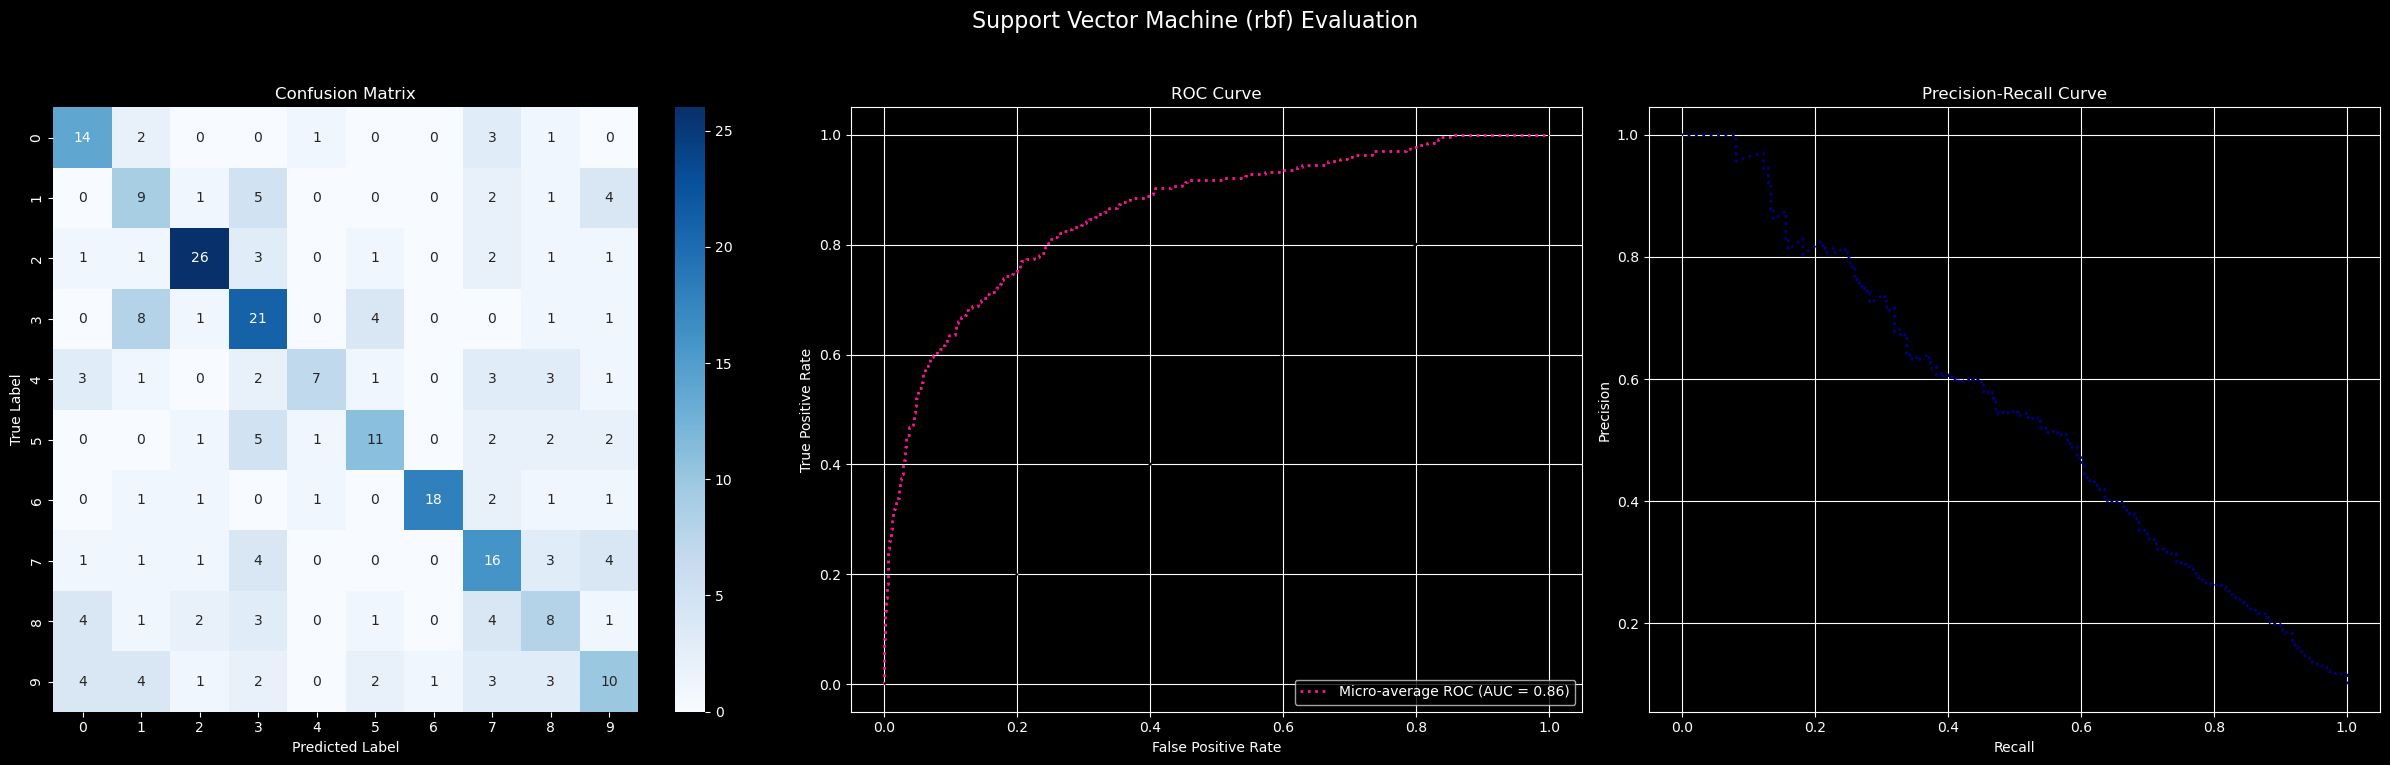


--- Kernel: sigmoid ---
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Train time: 1.04s
Best params for sigmoid kernel: {'C': 1, 'gamma': 'auto'}

==================== Evaluating Support Vector Machine (sigmoid) ====================
Accuracy: 0.3606
Weighted Precision: 0.4125
Weighted Recall: 0.3606
Weighted F-score: 0.3628



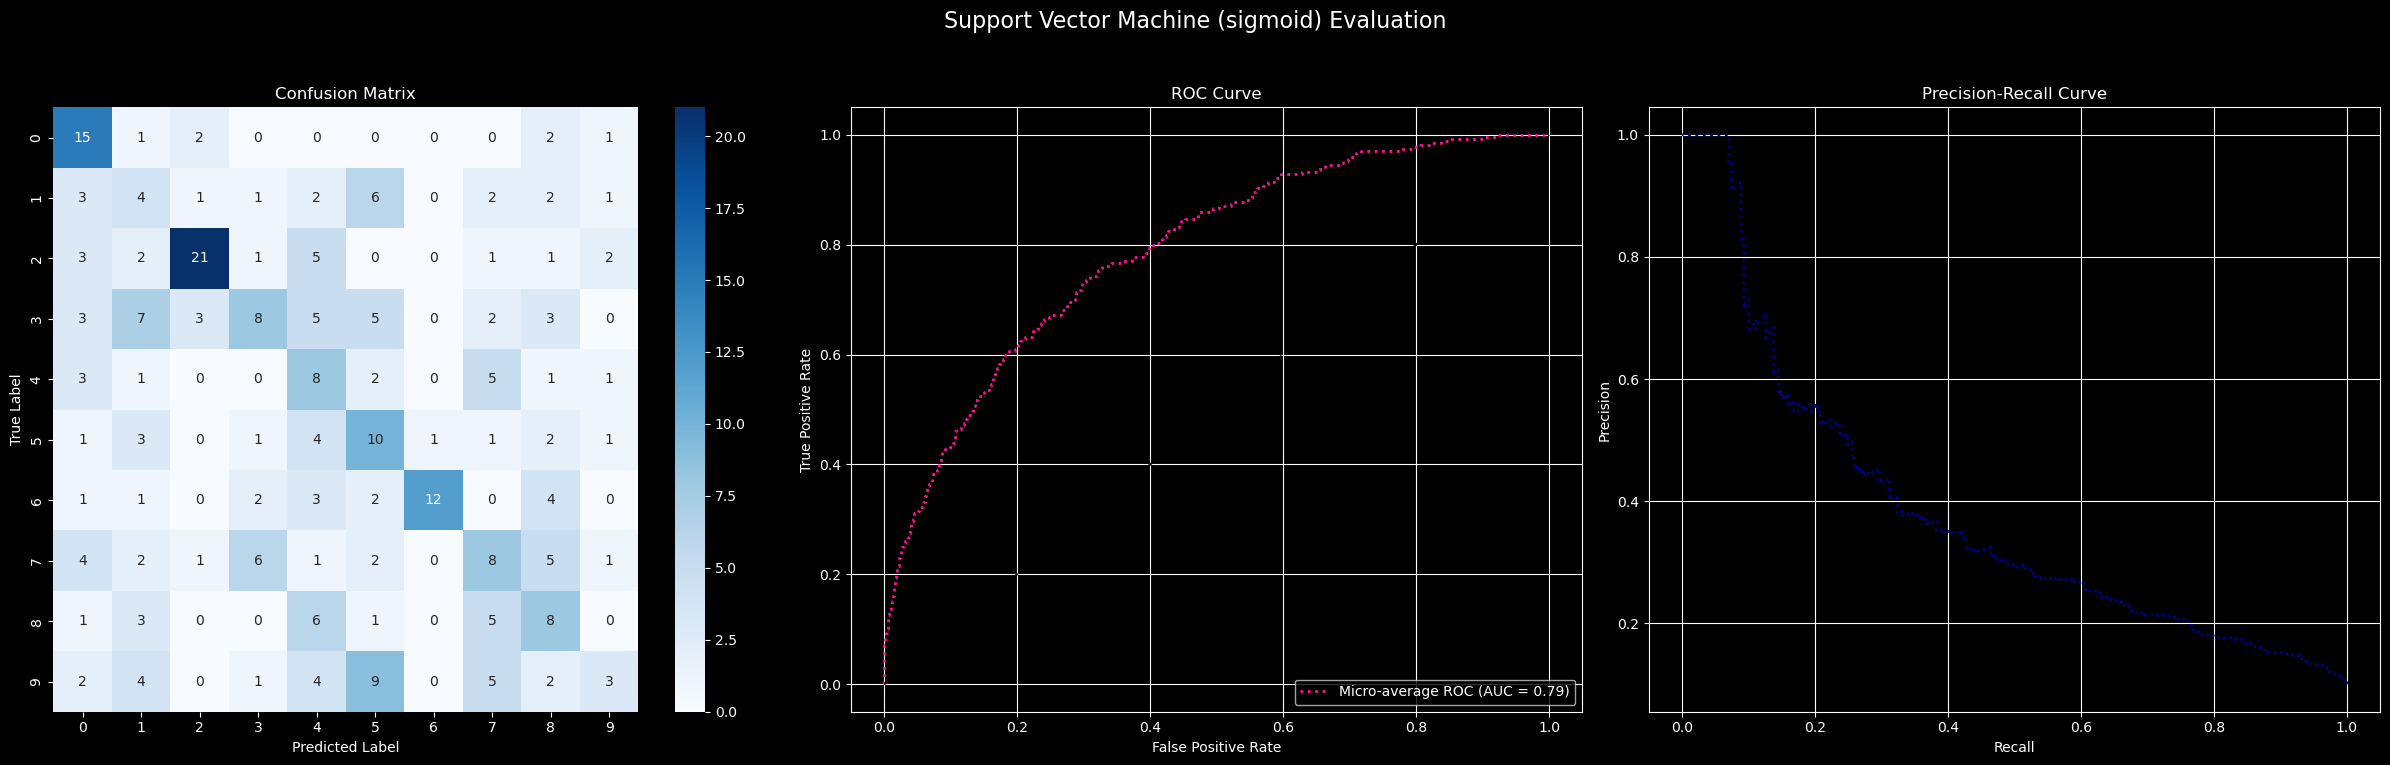

In [29]:
def train_SVM_model(X, y, kernel_list=['linear', 'poly', 'rbf', 'sigmoid']):
    print("--- Training SVC Model ---")

    print(f"Using a sample of {X.shape[0]} instances with {len(np.unique(y))} classes.")

    # Split
    X_train, y_train, X_test, y_test, _, _ = split(X, y)

    # Resample
    print("Applying SMOTE to the training data...")    
    smote = SMOTE(random_state=42, k_neighbors=2)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print(f"Training data shape after SMOTE: {X_train.shape}")

    for idx, kernel in enumerate(kernel_list):
        print(f"\n--- Kernel: {kernel} ---")
        base_model = SVC(kernel=kernel, degree=2, class_weight='balanced', probability=True)

        # Define parameter grid depending on kernel
        if kernel == 'linear':
            param_grid = {
                'C': [0.1, 1, 10]
            }
        elif kernel == 'rbf':
            param_grid = {
                'C': [0.1, 1, 10],
                'gamma': ['scale', 'auto', 0.1, 1]
            }
        elif kernel == 'poly':
            param_grid = {
                'C': [0.1, 1, 10],
                'degree': [2, 3, 4],
                'gamma': ['scale', 'auto']
            }
        elif kernel == 'sigmoid':
            param_grid = {
                'C': [0.1, 1, 10],
                'gamma': ['scale', 'auto']
            }
        else:
            print(f"Unsupported kernel: {kernel}")
            continue

        # Grid search
        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            scoring='accuracy',
            cv=3,
            verbose=1,
            n_jobs=-1
        )

        # Train
        start_train = time.time()
        grid_search.fit(X_train, y_train)
        print(f"Train time: {time.time() - start_train:.2f}s")
        print(f"Best params for {kernel} kernel:", grid_search.best_params_)

        best_model = grid_search.best_estimator_
        evaluate_model(best_model, X_test, y_test, model_name="Support Vector Machine (" + kernel + ")")

train_SVM_model(X_all, y)

### Perceptron

--- Training Perceptron Model ---
Using a sample of 1345 instances with 10 classes.
Applying SMOTE to the training data...
Training data shape after SMOTE: (1470, 19)

Training the model...
Logistic Regression train time: 0.01s
Best parameters: {'alpha': 0.001, 'eta0': 0.1, 'fit_intercept': True, 'max_iter': 500, 'penalty': 'elasticnet'}
Test accuracy: 0.3420074349442379

==================== Evaluating Best Perceptron Classifier ====================
Accuracy: 0.3420
Weighted Precision: 0.3585
Weighted Recall: 0.3420
Weighted F-score: 0.3415



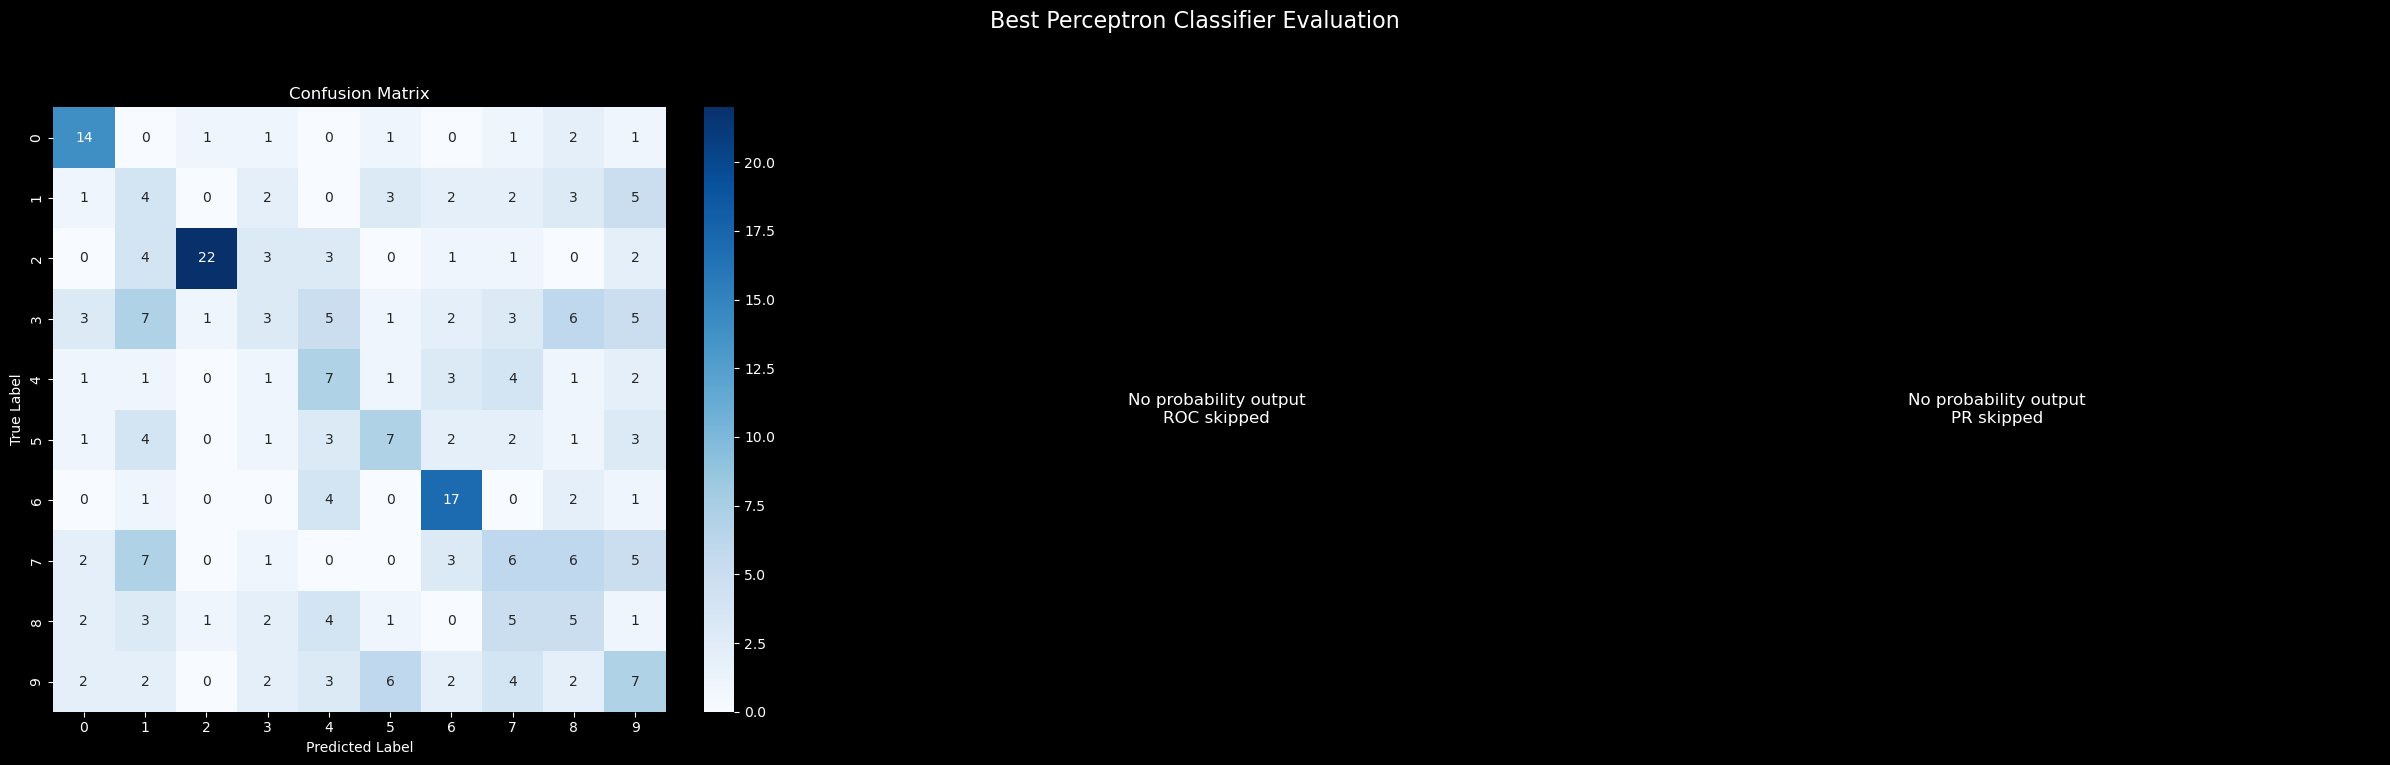

In [30]:
def train_Perceptron_model(X, y):
    """
    Trains, evaluates, and visualizes a Perceptron model.
    """
    print("--- Training Perceptron Model ---")

    # Sample and clean the data
    X_sampled, y_sampled = X, y
    print(f"Using a sample of {X_sampled.shape[0]} instances with {len(np.unique(y_sampled))} classes.")
    
    # Split data into training and testing sets
    X_train, y_train, X_test, y_test, _, _ = split(X_sampled, y_sampled, validation=False)

    # Handle class imbalance
    print("Applying SMOTE to the training data...")
    min_class_count = np.min(np.unique(y_train, return_counts=True)[1])
    k_neighbors = min(2, min_class_count - 1) if min_class_count > 1 else 1
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print(f"Training data shape after SMOTE: {X_train.shape}")


    # 5. Define and train the Logistic Regression model
    base_model = Perceptron(random_state=42)

    print("\nTraining the model...")
    start_train = time.time()
    base_model.fit(X_train, y_train)
    print(f"Logistic Regression train time: {time.time() - start_train:.2f}s")

    # find best model parameters using GridSearchCV

    param_grid = {
        'penalty': ['l2', 'l1', 'elasticnet', None],
        'alpha': [0.0001, 0.001, 0.01],
        'eta0': [0.1, 1.0, 10.0],
        'max_iter': [500, 1000, 2000],
        'fit_intercept': [True, False]
    }


    perceptron = Perceptron(random_state=42)

    grid_search = GridSearchCV(perceptron, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    # Best model
    best_model = grid_search.best_estimator_
    print("Best parameters:", grid_search.best_params_)

    # Evaluate on test set
    y_pred = best_model.predict(X_test)
    print("Test accuracy:", accuracy_score(y_test, y_pred))
    evaluate_model(best_model, X_test, y_test, model_name="Best Perceptron Classifier")




    

# Run the new function
train_Perceptron_model(X_all, y)




Sources:
- https://www.kaggle.com/competitions/birdclef-2025 (24.05.2025)
- https://www.kaggle.com/code/jocelyndumlao/birdclef-2025-mfcc-feature-roc-auc-analysis#Import-Libraries (24.05.2025)
- https://github.com/UtrechtUniversity/animal-sounds (24.05.2025)
- https://medium.com/analytics-vidhya/audio-data-processing-feature-extraction-science-concepts-behind-them-be97fbd587d8 (22.06.2025)
- https://medium.com/analytics-vidhya/audio-data-processing-feature-extraction-essential-science-concepts-behind-them-part-2-9c738e6a7f99 (22.06.2025)
- https://musicinformationretrieval.com/mfcc.html?source=post_page-----9c738e6a7f99--------------------------------------- (22.06.2025)
- https://en.wikipedia.org/wiki/Mel-frequency_cepstrum#:~:text=Mel%2Dfrequency%20cepstral%20coefficients%20(MFCCs,%2Da%2Dspectrum%22). (22.06.2025)
- https://scikit-learn.org/0.19/auto_examples/model_selection/plot_precision_recall.html (23.06.2025)
- https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html (23.06.2025)
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html (23.06.2025)
- https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/ (24.06.2025)
- https://datascience.stackexchange.com/questions/92471/weighted-accuracy-sensitivity-and-specificity (24.06.2025)
- https://stackoverflow.com/questions/51323595/plot-a-single-xgboost-decision-tree (24.06.2025)
- https://www.kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning (24.06.2025)



